# RNA Velocity via Neural ODEs — Neuro Dataset Analysis
**18.337/6.7320 Final Project — Nirali Somia, Emilie de Vet, Antonio Rios**

---

## Overview

This notebook applies the RNA velocity pipeline to a **neural differentiation dataset** (Dentate Gyrus, La Manno et al. 2018), implemented entirely in Julia using the SciML ecosystem. It is a companion to the main `project_28April.ipynb` notebook, focusing on the neuro system rather than bone marrow.

The dataset was obtained via `download_lamanno.ipynb` and saved as `lamanno_data/dentategyrus_velocity.h5ad`.

The analysis is organized into three sections:

1. **§4.1 — Mechanistic RNA Velocity** — function library implementing the steady-state (La Manno et al. 2018) and dynamical (Bergen et al. 2020) models, velocity graph construction, and Neural ODE formulation
2. **§4.2 — Neuro Dataset Analysis** (Dentate Gyrus) — full pipeline run on the neuro dataset: preprocessing, velocity estimation, embedding projection, and biological validation
3. **§4.4 — Neural ODE on Neuro Data** — learns a continuous vector field in PCA space and simulates neuronal differentiation trajectories

### RNA Velocity in brief

RNA velocity exploits the fact that unspliced pre-mRNA ($u$) and spliced mRNA ($s$) are produced sequentially. The ratio of $u$ to $s$ encodes whether a gene is currently being upregulated or downregulated, giving each cell a velocity vector in gene expression space that predicts its near-future state.

### Dataset: Dentate Gyrus (La Manno et al. 2018)
- **Cells**: ~2,930 neurons  
- **Tissue**: Mouse dentate gyrus (hippocampus)  
- **Layers**: `spliced`, `unspliced`, `ambiguous`  
- **Biology**: Neurogenesis — radial glia → granule cell precursors → mature neurons


## 0. Environment Setup

All packages are loaded up-front to trigger Julia's precompilation before the analysis begins.

| Package group | Purpose |
|---|---|
| `DifferentialEquations`, `OrdinaryDiffEq`, `SciMLSensitivity` | ODE solvers and adjoint-based gradients for Neural ODE integration |
| `Lux`, `Zygote`, `Optimisers`, `ComponentArrays` | Neural network definition, automatic differentiation, gradient-based training |
| `MultivariateStats`, `NearestNeighbors` | PCA (for velocity projection) and kNN graph construction |
| `HDF5` | Reading `.h5ad` (AnnData) files from Python-based scRNA-seq workflows |
| `CairoMakie` | Publication-quality static plots |
| `BSON` | Saving and reloading fitted model parameters across sessions |


In [1]:
ENV["JULIA_WARN_COLOR"] = "default"
# or more aggressively, filter precompile warnings:
Base.CoreLogging.disable_logging(Base.CoreLogging.Warn)


LogLevel(1001)

In [2]:
using Pkg

using DifferentialEquations
using OrdinaryDiffEq
using SciMLSensitivity
using Lux
using Optimisers
using Zygote
using ComponentArrays
using Statistics
using LinearAlgebra
using Random
using Distributions
using StatsBase
using MultivariateStats   # for PCA
using NearestNeighbors
using SparseArrays
using HDF5
using CairoMakie
# Resolve Axis ambiguity: ComponentArrays and CairoMakie both export Axis
import CairoMakie: Axis
using ProgressMeter
using BSON: @save, @load

rng = Random.default_rng()
Random.seed!(rng, 42)
println("Environment ready.")


Environment ready.


---
## §4.1 — Mechanistic RNA Velocity

### 1.1 Steady-State Model (La Manno et al. 2018)

At steady state $\frac{du}{dt}=0$, we get $u^* = \alpha/\beta$. Defining $\gamma' = \gamma/\beta$, the velocity of spliced mRNA is:
$$v_s = \frac{ds}{dt} = \beta u - \gamma s$$
Estimating $\gamma'$ by linear regression of $s$ on $u$ at steady state, the velocity vector for each cell is $v_s = \hat{\beta} u - \hat{\gamma} s$.

### 1.2 Dynamical Model (Bergen et al. 2020)

Lifts the steady-state assumption. Each gene is modelled with a two-phase ODE:
$$\frac{du}{dt} = \alpha(t) - \beta u, \quad \frac{ds}{dt} = \beta u - \gamma s$$
where $\alpha(t) = \alpha$ during induction ($t < t_{\text{switch}}$) and $0$ during repression. Parameters $(\alpha, \beta, \gamma, t_{\text{switch}})$ are estimated per gene via an EM algorithm that alternates between assigning each cell a latent time and optimizing parameters by gradient descent.

---

### Implementation overview — cells in this section

The following code cells define all functions used throughout the notebook. No computations are run here.

| Cells | Contents |
|---|---|
| Data structures & preprocessing | `AnnData` struct, `normalize_total!`, `log1p_transform!`, `filter_genes` |
| Parameter estimation | `knn_pool`, `estimate_gammas` (steady-state γ) |
| Dynamical model | `RNAVelocityParams`, closed-form ODE solutions, `fit_gene_params_em` (EM loop) |
| Full pipeline | `run_rna_velocity!` (steady-state and dynamical) |
| Velocity graph | `build_velocity_graph`, `project_velocity_embedding`, `velocity_confidence` |
| Neural ODE | PCA projection, `build_velocity_network`, `train_neural_ode`, `simulate_trajectories` |
| Data loading | `load_h5ad`, `benchmark_velocity` |
| Visualization | `plot_velocity_embedding`, `plot_phase_portrait`, `plot_trajectories_pca` |


### Data structures & preprocessing

`AnnData` mirrors the Python anndata object used by scVelo, storing count matrices, cell/gene metadata, low-dimensional embeddings, and computed results in one container. The preprocessing functions apply library-size normalization, log1p transform, and top-HVG selection — the same steps as the scVelo Python pipeline.


In [3]:
# ─────────────────────────────────────────────────────────────────
# Data structures
# ─────────────────────────────────────────────────────────────────

struct AnnData
    X::Matrix{Float32}          # (cells × genes) spliced counts
    layers::Dict{String, Matrix{Float32}}  # e.g. "spliced", "unspliced"
    obs::Dict{String, Vector}   # cell metadata
    var::Dict{String, Vector}   # gene metadata
    obsm::Dict{String, Matrix{Float32}}   # embeddings (umap, pca, ...)
    uns::Dict{String, Any}      # unstructured metadata
end

function AnnData(X::Matrix{Float32};
        layers=Dict{String,Matrix{Float32}}(),
        obs=Dict{String,Vector}(),
        var=Dict{String,Vector}(),
        obsm=Dict{String,Matrix{Float32}}(),
        uns=Dict{String,Any}())
    AnnData(X, layers, obs, var, obsm, uns)
end

n_cells(adata::AnnData) = size(adata.X, 1)
n_genes(adata::AnnData) = size(adata.X, 2)

println("AnnData struct defined.")


AnnData struct defined.


In [4]:
# ─────────────────────────────────────────────────────────────────
# Preprocessing
# ─────────────────────────────────────────────────────────────────

"""
    normalize_total!(adata; target_sum=1f4)

Library-size normalize each cell so counts sum to `target_sum`, then log1p transform.
Applied in-place to both spliced and unspliced layers.
"""
function normalize_total!(adata::AnnData; target_sum::Float32=1f4)
    for key in ("spliced", "unspliced")
        haskey(adata.layers, key) || continue
        M = adata.layers[key]           # cells × genes
        row_sums = sum(M, dims=2)       # cells × 1
        row_sums[row_sums .== 0] .= 1f0
        adata.layers[key] = (M ./ row_sums) .* target_sum
    end
    # Also normalize X
    row_sums = sum(adata.X, dims=2)
    row_sums[row_sums .== 0] .= 1f0
    adata.X .= (adata.X ./ row_sums) .* target_sum
    return adata
end

"""
    log1p_transform!(adata)

Apply log(1+x) to all count matrices.
"""
function log1p_transform!(adata::AnnData)
    adata.X .= log1p.(adata.X)
    for key in keys(adata.layers)
        adata.layers[key] .= log1p.(adata.layers[key])
    end
    return adata
end

"""
    filter_genes!(adata; min_shared_counts=30, n_top_genes=2000)

Keep only genes detected in both spliced and unspliced layers with sufficient counts,
then select the top highly-variable genes by variance.
"""
function filter_genes(adata::AnnData; min_shared_counts::Int=30, n_top_genes::Int=2000)
    s = get(adata.layers, "spliced",  adata.X)
    u = get(adata.layers, "unspliced", adata.X)

    # Keep genes where both layers have sufficient total counts
    s_total = vec(sum(s, dims=1))
    u_total = vec(sum(u, dims=1))
    shared_mask = (s_total .>= min_shared_counts) .& (u_total .>= min_shared_counts)

    # Among those, pick top by variance in spliced layer
    shared_idx = findall(shared_mask)
    vars = vec(var(s[:, shared_idx], dims=1))
    top_k = min(n_top_genes, length(shared_idx))
    top_idx = shared_idx[sortperm(vars, rev=true)[1:top_k]]

    new_layers = Dict(k => v[:, top_idx] for (k, v) in adata.layers)
    new_X = adata.X[:, top_idx]
    new_var = Dict(k => v[top_idx] for (k, v) in adata.var)

    return AnnData(new_X; layers=new_layers, obs=adata.obs, var=new_var,
                   obsm=adata.obsm, uns=adata.uns)
end

println("Preprocessing functions defined.")


Preprocessing functions defined.


In [5]:
# ─────────────────────────────────────────────────────────────────
# Gene-wise parameter estimation
# ─────────────────────────────────────────────────────────────────

"""
    knn_pool(M, X_pca; k=30) -> M_pooled::Matrix{Float32}

kNN cell pooling (La Manno 2018): for each cell, replace its count vector
with the mean across its k nearest neighbours (including itself).
This dramatically reduces per-gene sparsity before fitting γ.

M: (N × G) count matrix (spliced or unspliced)
X_pca: (N × d) PCA coordinates used to define cell neighbourhoods
"""
function knn_pool(M::Matrix{Float32}, X_pca::Matrix{Float32}; k::Int=30)
    N = size(M, 1)
    kdtree = KDTree(X_pca')
    idxs, _ = knn(kdtree, X_pca', k, true)
    M_pooled = similar(M)
    for i in 1:N
        M_pooled[i, :] = vec(mean(M[idxs[i], :], dims=1))
    end
    return M_pooled
end

# Helper: compute percentile
percentile_(x::AbstractVector, p::Float64) = quantile(x, p/100)

"""
    spearman_cor(x, y) -> Float32

Spearman rank correlation between two vectors.
"""
function spearman_cor(x::Vector{Float32}, y::Vector{Float32})
    n = length(x)
    n < 3 && return 0f0
    rx = Float32.(invperm(sortperm(x)))
    ry = Float32.(invperm(sortperm(y)))
    return Float32(cor(rx, ry))
end

"""
    estimate_gammas(s, u; hi_pct=95, lo_pct=5, min_gamma, min_r) -> (γ, mask)

Steady-state slope estimation matching La Manno 2018 Supplementary Note 2 §2.

The phase portrait of u vs s has two steady-state anchors:
  - Upper-right corner (high s + u): cells near the induction steady state
  - Origin (low s + u):             cells near the repression steady state

Using BOTH anchor regions for the OLS gives an unbiased γ estimate even for
transient genes that are never close to just one steady state. Using only the
upper quantile (as many implementations do) systematically underestimates γ
because the regression loses the origin-anchoring lower-quantile cells.

Quality filters:
  - min_gamma: discard genes with γ < min_gamma (degenerate / near-zero slope)
  - min_r:     discard genes with Spearman(s, u) < min_r (no phase-space structure)

Returns (γ::Vector{Float32}, good::BitVector).
"""
function estimate_gammas(s::Matrix{Float32}, u::Matrix{Float32};
                         hi_pct::Float64=95.0,
                         lo_pct::Float64=5.0,
                         min_gamma::Float32=0.01f0,
                         min_r::Float32=0.1f0)
    G = size(s, 2)
    γ = zeros(Float32, G)
    good = trues(G)
    for g in 1:G
        sg = s[:, g]
        ug = u[:, g]

        # Gene quality: Spearman correlation between s and u
        r = spearman_cor(sg, ug)
        if r < min_r
            good[g] = false
            continue
        end

        # Select cells in BOTH extreme quantiles of (s + u):
        #   upper quantile → near induction steady state (upper-right of phase portrait)
        #   lower quantile → near repression steady state (near origin)
        # This two-anchor fit is the velocyto convention; it prevents γ bias on
        # transient genes that have no cells near one of the two steady states.
        total = sg .+ ug
        hi_thresh = percentile_(total, hi_pct)
        lo_thresh = percentile_(total, lo_pct)
        mask = (total .>= hi_thresh) .| (total .<= lo_thresh)
        sum(mask) < 5 && (mask = trues(length(sg)))

        ss = sg[mask]
        uu = ug[mask]
        # OLS through origin for u ≈ γ*s: γ = (s'·s)⁻¹ (s'·u)
        denom = dot(ss, ss)
        γ_g = denom > 0 ? dot(ss, uu) / denom : 0f0

        # Gene quality: minimum gamma
        if γ_g < min_gamma
            good[g] = false
            continue
        end
        γ[g] = γ_g
    end
    return γ, good
end

"""
    compute_velocity_steady_state(s, u, γ) -> V::Matrix{Float32}

RNA velocity under steady-state model:
    v_g(cell) = u_g - γ_g * s_g

Returns a (cells × genes) velocity matrix.
Positive v means gene g is being upregulated in that cell;
negative v means downregulation.
"""
function compute_velocity_steady_state(s::Matrix{Float32}, u::Matrix{Float32},
                                        γ::Vector{Float32})
    return u .- s .* γ'  # (N × G)
end

println("Parameter estimation functions defined.")


Parameter estimation functions defined.


### Dynamical model: ODE system & per-gene parameter estimation

`fit_gene_params_em` runs the EM loop: the E-step assigns each cell to the nearest point on a precomputed trajectory grid (cheap closed-form evaluation); the M-step minimizes reconstruction MSE in $(u, s)$ space via 20 steps of Zygote gradient descent on the unconstrained reparameterization of $(\alpha, \beta, \gamma, t_{\text{switch}})$.


In [6]:
# ─────────────────────────────────────────────────────────────────
# Dynamical model (Bergen et al. 2020 — scVelo-style)
# ─────────────────────────────────────────────────────────────────

"""
    RNAVelocityParams

Holds gene-wise rate parameters estimated under the full dynamical model.
"""
struct RNAVelocityParams
    α::Vector{Float32}   # transcription rates
    β::Vector{Float32}   # splicing rates
    γ::Vector{Float32}   # degradation rates
    t_::Vector{Float32}  # switching times (induction→repression)
end

"""
    rna_ode!(du, u, p, t)

Single-gene RNA velocity ODE system for one gene:
    du/dt = α(t) - β*u
    ds/dt = β*u  - γ*s
where α(t) = α during induction phase (t < t_switch), 0 during repression.
"""
function rna_ode!(du, u_state, p, t)
    α, β, γ, t_switch = p
    α_t = t < t_switch ? α : 0f0
    du[1] = α_t - β * u_state[1]   # d(unspliced)/dt
    du[2] = β * u_state[1] - γ * u_state[2]  # d(spliced)/dt
end

"""
    solve_gene_trajectory(α, β, γ, t_switch; tspan=(0f0, 20f0), n_points=200)

Integrate the ODE for a single gene and return the (u, s) trajectory.
"""
function solve_gene_trajectory(α::Float32, β::Float32, γ::Float32, t_switch::Float32;
                                tspan=(0f0, 20f0), n_points::Int=200)
    u0 = [0f0, 0f0]  # start from zero
    p  = (α, β, γ, t_switch)
    prob = ODEProblem(rna_ode!, u0, tspan, p)
    sol  = solve(prob, Tsit5(); saveat=range(tspan[1], tspan[2], length=n_points))
    return sol
end

println("Mechanistic ODE model defined.")


Mechanistic ODE model defined.


In [7]:
# ─────────────────────────────────────────────────────────────────
# Dynamical RNA velocity fitting (stabilized EM + bounded optimization)
# ─────────────────────────────────────────────────────────────────

"""
    steady_state_u(α, β)  -> u*
    steady_state_s(α, β, γ) -> s*
"""
steady_state_u(α, β) = α / β
steady_state_s(α, β, γ) = α / γ

# Numerically stable helpers
softplus(x) = log1p(exp(-abs(x))) + max(x, 0f0)
sigmoid(x) = 1f0 / (1f0 + exp(-x))

"""
    analytical_u(t, α, β, u0)
    analytical_s(t, α, β, γ, u0, s0)

Closed-form solution of:
  du/dt = α - βu
  ds/dt = βu - γs
"""
analytical_u(t, α, β, u0) = u0 * exp(-β*t) + (α/β) * (1 - exp(-β*t))

function analytical_s(t, α, β, γ, u0, s0)
    if abs(β - γ) < 1f-6
        return s0 * exp(-γ*t) + (α/γ) * (1 - exp(-γ*t)) +
               β * (u0 - α/β) * t * exp(-γ*t)
    else
        c1 = β * (u0 - α/β) / (γ - β)
        return (s0 - α/γ - c1) * exp(-γ*t) + c1 * exp(-β*t) + α/γ
    end
end

"""
    predict_us(t, α, β, γ, t_switch)

Piecewise trajectory with induction (α>0) then repression (α=0).
"""
function predict_us(t::Float32, α::Float32, β::Float32, γ::Float32, t_switch::Float32)
    if t <= t_switch
        u = analytical_u(t, α, β, 0f0)
        s = analytical_s(t, α, β, γ, 0f0, 0f0)
    else
        u_sw = analytical_u(t_switch, α, β, 0f0)
        s_sw = analytical_s(t_switch, α, β, γ, 0f0, 0f0)
        τ = t - t_switch
        u = analytical_u(τ, 0f0, β, u_sw)
        s = analytical_s(τ, 0f0, β, γ, u_sw, s_sw)
    end
    return u, s
end

"""
    assign_latent_times(u_obs, s_obs, α, β, γ, t_switch; n_t=60, t_end=20)

Fast E-step: assign each cell to nearest point on a precomputed trajectory grid.
"""
function assign_latent_times(u_obs::Vector{Float32}, s_obs::Vector{Float32},
                             α::Float32, β::Float32, γ::Float32, t_switch::Float32;
                             n_t::Int=60, t_end::Float32=20f0)
    N = length(u_obs)
    t_grid = collect(range(0f0, t_end, length=2*n_t))

    u_grid = similar(t_grid)
    s_grid = similar(t_grid)
    for k in eachindex(t_grid)
        u_grid[k], s_grid[k] = predict_us(t_grid[k], α, β, γ, t_switch)
    end

    t_latent = zeros(Float32, N)
    phases = fill(:induction, N)

    for i in 1:N
        ui, si = u_obs[i], s_obs[i]
        best_k = 1
        best_d = Inf32
        for k in eachindex(t_grid)
            d = (ui - u_grid[k])^2 + (si - s_grid[k])^2
            if d < best_d
                best_d = d
                best_k = k
            end
        end
        t_latent[i] = t_grid[best_k]
        phases[i] = t_latent[i] <= t_switch ? :induction : :repression
    end
    return t_latent, phases
end

"""
    fit_gene_params_em(u_obs, s_obs; ...)

Stabilized EM-style fit for (α, β, γ, t_switch):
- Optional supervised latent time from pseudotime (`t_obs`)
- Bounded parameterization via softplus/sigmoid to avoid collapse
- Lightweight gradient M-step on reconstruction error in (u,s)
"""
function fit_gene_params_em(u_obs::Vector{Float32}, s_obs::Vector{Float32};
                            n_iter::Int=6,
                            n_t::Int=60,
                            gd_steps::Int=20,
                            lr::Float32=3f-2,
                            t_end::Float32=20f0,
                            t_obs::Union{Nothing, Vector{Float32}}=nothing)
    N = length(u_obs)

    # Initialize from moments
    α0 = clamp(mean(u_obs), 1f-3, 50f0)
    β0 = 1f0
    γ0 = clamp(sum(u_obs .* s_obs) / max(1f-6, sum(u_obs .^ 2)), 1f-3, 10f0)
    t0 = isnothing(t_obs) ? (0.35f0 * t_end) : clamp(median(t_obs), 1f0, t_end - 1f0)

    # Raw unconstrained params
    raw = Float32[log(exp(α0)-1f0), log(exp(β0)-1f0), log(exp(γ0)-1f0), 0f0]

    unpack(rawv) = begin
        α = softplus(rawv[1]) + 1f-4
        β = softplus(rawv[2]) + 1f-4
        γ = softplus(rawv[3]) + 1f-4
        # keep away from hard bounds to prevent degeneracy
        t_switch = 1f0 + (t_end - 2f0) * sigmoid(rawv[4])
        α, β, γ, t_switch
    end

    # Use external pseudotime if provided; otherwise do EM latent-time assignment
    t_lat = isnothing(t_obs) ? fill(t0, N) : clamp.(t_obs, 0f0, t_end)

    function reconstruction_loss(rawv, t_vec)
        α, β, γ, t_switch = unpack(rawv)
        acc = 0f0
        @inbounds for i in 1:N
            up, sp = predict_us(t_vec[i], α, β, γ, t_switch)
            du = up - u_obs[i]
            ds = sp - s_obs[i]
            acc += du*du + ds*ds
        end
        acc / N
    end

    for _ in 1:n_iter
        if isnothing(t_obs)
            α, β, γ, t_switch = unpack(raw)
            t_lat, _ = assign_latent_times(u_obs, s_obs, α, β, γ, t_switch; n_t=n_t, t_end=t_end)
        end

        # M-step: optimize params with fixed latent times
        for _ in 1:gd_steps
            grads = Zygote.gradient(rv -> reconstruction_loss(rv, t_lat), raw)[1]
            grads = clamp.(grads, -10f0, 10f0)
            raw .-= lr .* grads
        end
    end

    α, β, γ, t_switch = unpack(raw)
    return (α=Float32(α), β=Float32(β), γ=Float32(γ), t_switch=Float32(t_switch))
end

"""
    compute_velocity_dynamical(u_obs, s_obs, params)
"""
function compute_velocity_dynamical(u_obs::Vector{Float32}, s_obs::Vector{Float32},
                                    params::NamedTuple)
    return params.β .* u_obs .- params.γ .* s_obs
end

println("Stabilized dynamical model defined.")


Stabilized dynamical model defined.


### Full pipeline: `run_rna_velocity!`

Orchestrates the full pipeline for either model: kNN pooling → γ estimation → per-gene velocity (parallelised with `Threads.@threads`) → quality filtering. The dynamical branch optionally uses Palantir pseudotime to supervise the E-step latent time assignment, improving convergence on multi-lineage datasets.


In [8]:
# ─────────────────────────────────────────────────────────────────
# Full RNA velocity pipeline
# ─────────────────────────────────────────────────────────────────

"""
    run_rna_velocity!(adata; ...)

Top-level RNA velocity runner. Adds:
  - adata.layers["velocity"]: (N × G) velocity matrix
  - adata.uns["velocity_params"]: per-gene (α, β, γ, t_switch)
  - adata.uns["velocity_genes"]: Bool mask of genes that passed quality filters

Options:
  - `pool_key`: obsm key for PCA coordinates used for kNN pooling (La Manno 2018).
                If present, u and s are smoothed over k nearest neighbors before
                fitting γ, dramatically reducing sparsity noise.
  - `pool_k`:   number of neighbors for pooling (paper uses 30–550)
  - `min_gamma`, `min_r`: gene quality filters (paper: γ≥0.1, Spearman≥0 in R impl)
"""
function run_rna_velocity!(adata::AnnData;
                           model::Symbol=:steady_state,
                           pool_key::Union{Nothing, String}="X_pca",
                           pool_k::Int=30,
                           min_gamma::Float32=0.01f0,
                           min_r::Float32=0.1f0,
                           use_pseudotime::Bool=true,
                           pseudotime_key::Union{Nothing, String}=nothing,
                           max_cells_per_gene::Int=1200,
                           n_iter::Int=6,
                           n_t::Int=60,
                           gd_steps::Int=20,
                           lr::Float32=3f-2,
                           t_end::Float32=20f0)
    s = adata.layers["spliced"]
    u = adata.layers["unspliced"]
    G = n_genes(adata)
    N = n_cells(adata)

    # ── kNN pooling (La Manno 2018) ───────────────────────────────
    s_fit = s
    u_fit = u
    if !isnothing(pool_key) && haskey(adata.obsm, pool_key)
        X_pca = adata.obsm[pool_key][:, 1:min(50, size(adata.obsm[pool_key], 2))]
        println("Applying kNN pooling (k=$pool_k) using embedding '$pool_key'...")
        s_fit = knn_pool(s, X_pca; k=pool_k)
        u_fit = knn_pool(u, X_pca; k=pool_k)
        println("Pooling complete.")
    else
        println("No PCA embedding found for pooling — fitting on raw counts.")
    end

    # ── Estimate γ on pooled data ─────────────────────────────────
    println("Estimating γ for $G genes...")
    γ_all, gene_mask = estimate_gammas(s_fit, u_fit;
                                       min_gamma=min_gamma, min_r=min_r)
    n_good = sum(gene_mask)
    println("  $n_good / $G genes passed quality filters (γ≥$min_gamma, Spearman≥$min_r)")

    V = zeros(Float32, N, G)
    # Pre-fill with a zero/NaN sentinel so filtered genes have a valid entry
    params_list = [(α=NaN32, β=1f0, γ=0f0, t_switch=NaN32) for _ in 1:G]

    # ── Optional pseudotime supervision for dynamical fitting ─────
    t_obs_all = nothing
    if model == :dynamical && use_pseudotime
        key = isnothing(pseudotime_key) ?
              (haskey(adata.obs, "palantir_pseudotime") ? "palantir_pseudotime" : nothing) :
              pseudotime_key
        if !isnothing(key) && haskey(adata.obs, key)
            pt_raw = Float32.(adata.obs[key])
            valid = .!isnan.(pt_raw)
            if any(valid)
                pmin = minimum(pt_raw[valid])
                pmax = maximum(pt_raw[valid])
                if pmax > pmin
                    t_obs_all = similar(pt_raw)
                    t_obs_all .= 0f0
                    t_obs_all[valid] .= ((pt_raw[valid] .- pmin) ./ (pmax - pmin)) .* t_end
                    println("Using pseudotime supervision from obs['$key'].")
                end
            end
        end
    end

    # One RNG per thread — avoids a data race on the global rng when the
    # dynamical model subsamples cells inside the parallel gene loop.
    thread_rngs = [Random.MersenneTwister(42 + t) for t in 1:Threads.maxthreadid()]

    println("Computing velocity for $G genes across $N cells (model=$model, $(Threads.nthreads()) threads)...")
    prog = Progress(G; desc="  genes: ")
    Threads.@threads for g in 1:G
        sg = s_fit[:, g]
        ug = u_fit[:, g]
        γ_g = γ_all[g]

        if model == :steady_state
            V[:, g] = ug .- γ_g .* sg
            params_list[g] = (α=NaN32, β=1f0, γ=γ_g, t_switch=NaN32)

        elseif model == :dynamical
            trng = thread_rngs[Threads.threadid()]
            idx_fit = N > max_cells_per_gene ? randperm(trng, N)[1:max_cells_per_gene] : collect(1:N)
            ug_fit_g = ug[idx_fit]
            sg_fit_g = sg[idx_fit]
            t_fit = isnothing(t_obs_all) ? nothing : t_obs_all[idx_fit]

            p = try
                fit_gene_params_em(ug_fit_g, sg_fit_g;
                                   n_iter=n_iter, n_t=n_t,
                                   gd_steps=gd_steps, lr=lr,
                                   t_end=t_end, t_obs=t_fit)
            catch
                (α=mean(ug_fit_g), β=1f0, γ=γ_g, t_switch=t_end * 0.35f0)
            end
            V[:, g] = compute_velocity_dynamical(ug, sg, p)
            params_list[g] = p

        else
            error("Unknown model: $model. Use :steady_state or :dynamical.")
        end
        next!(prog)
    end

    # Zero out velocities for genes that failed quality filters
    V[:, .!gene_mask] .= 0f0

    adata.layers["velocity"] = V
    adata.uns["velocity_params"] = params_list
    adata.uns["velocity_genes"] = gene_mask
    println("Done. Velocity stored in adata.layers[\"velocity\"].")
    return adata
end

println("Full pipeline defined.")


Full pipeline defined.


---
## §4.1 Continued — Velocity Graph & Cell-level Projection

The velocity of each cell in a low-dimensional embedding is computed by projecting the high-dimensional velocity vector onto the transition probabilities to neighboring cells in the KNN graph.


In [9]:
using SparseArrays
using NearestNeighbors

# ─────────────────────────────────────────────────────────────────
# Velocity graph: transition probabilities via cosine similarity
# ─────────────────────────────────────────────────────────────────

"""
    build_velocity_graph(X, V; n_neighbors=30, scale=10.0)

Compute transition probability matrix T where T[i,j] is proportional to
exp( cosine_similarity(V_i, X_j - X_i) ) for neighbors j of cell i.

This encodes whether the velocity vector of cell i points toward cell j.
Returns a sparse N×N transition matrix (all non-negative entries).

Implementation note — `use_negative_cosines`:
scVelo separates this into two steps: (1) a signed cosine similarity graph
π_ij = cos(V_i, X_j - X_i), then (2) a softmax kernel T̃_ij = exp(π_ij/σ).
With `use_negative_cosines=True` (scVelo default), negative cosines contribute
a *repulsive* signal: a neighbor the velocity points *away from* gets weight
exp(-|cos|/σ) < 1/n_neighbors, actively pushing the transition toward other cells.
Here we combine both steps into T[i,j] ∝ exp(scale·cos_sim), so negative
cosines yield tiny positive weights (~0.007 for cos=-0.5) rather than
contributing repulsive signal. The result is slightly less directional at
progenitor cluster edges but functionally equivalent for typical datasets.
If you need signed-cosine behavior (e.g., for CellRank), split into:
  (1) cos_graph = cosine_similarity_matrix(X, V)
  (2) T = exp.(cos_graph ./ σ)  with cos_graph ≤ 0 set to −∞ or kept signed.
"""
function build_velocity_graph(X::Matrix{Float32}, V::Matrix{Float32};
                               n_neighbors::Int=30, scale::Float64=10.0)
    N = size(X, 1)
    kdtree = KDTree(X')
    idxs, _ = knn(kdtree, X', n_neighbors+1, true)

    Is = Int[]
    Js = Int[]
    Vs_sp = Float32[]

    for i in 1:N
        vi = V[i, :]
        vi_norm = norm(vi)
        vi_norm < 1f-10 && continue

        neighbors = filter(j -> j != i, idxs[i])
        weights = Float32[]
        for j in neighbors
            dij = X[j, :] - X[i, :]
            dij_norm = norm(dij)
            cos_sim = dij_norm < 1f-10 ? 0f0 : dot(vi, dij) / (vi_norm * dij_norm)
            push!(weights, exp(Float32(scale) * cos_sim))
        end

        w_sum = sum(weights)
        w_sum < 1f-10 && continue
        weights ./= w_sum  # normalize to probabilities

        for (k, j) in enumerate(neighbors)
            push!(Is, i)
            push!(Js, j)
            push!(Vs_sp, weights[k])
        end
    end

    return sparse(Is, Js, Vs_sp, N, N)
end

"""
    project_velocity_embedding(X_embed, T_graph) -> V_embed::Matrix{Float32}

Project velocity arrows into a 2D embedding (e.g. tSNE, UMAP).

Matches scVelo's `velocity_embedding.py` exactly:

    V_emb[i] = Σ_j (π̃_ij − p̄_i) · δ̃_ij

where δ̃_ij = (X_j - X_i) / ‖X_j - X_i‖  (unit displacement)
and   p̄_i  = mean(π̃_ij for j ∈ neighbors(i))  (neighborhood mean weight)

The mean-subtraction is the *density-drift correction*: it cancels the
systematic bias that arises when a cell's embedding neighborhood is
asymmetric (boundary cells, cells near cluster edges). Without it, arrows
at cluster boundaries point toward the denser region regardless of velocity
— an artifact of the local kNN geometry, not biology.
"""
function project_velocity_embedding(X_embed::Matrix{Float32},
                                     T_graph::SparseMatrixCSC{Float32})
    N = size(X_embed, 1)
    d = size(X_embed, 2)
    V_embed = zeros(Float32, N, d)

    # First pass: accumulate unit-displacement vectors and weights per cell
    # to compute the neighborhood mean weight p̄_i
    rows, cols, vals = findnz(T_graph)

    # Count neighbors and sum weights per cell (for mean computation)
    weight_sum = zeros(Float32, N)    # Σ_j π̃_ij
    n_neighbors = zeros(Int, N)       # number of actual neighbors
    disp_sum = zeros(Float32, N, d)   # Σ_j δ̃_ij (sum of unit displacements)

    for k in eachindex(rows)
        i, j = rows[k], cols[k]
        disp = X_embed[j, :] .- X_embed[i, :]
        dn = norm(disp)
        dn < 1f-10 && continue
        unit_disp = disp ./ dn
        weight_sum[i]    += vals[k]
        n_neighbors[i]   += 1
        disp_sum[i, :]   .+= unit_disp
        V_embed[i, :]    .+= vals[k] .* unit_disp
    end

    # Second pass: subtract density-drift correction p̄_i * Σ_j δ̃_ij
    # p̄_i = weight_sum[i] / n_neighbors[i]  (mean transition probability)
    for i in 1:N
        n_neighbors[i] == 0 && continue
        p_bar = weight_sum[i] / n_neighbors[i]
        V_embed[i, :] .-= p_bar .* disp_sum[i, :]
    end

    return V_embed
end


"""
    compute_velocity_consistency(T_graph, cell_types) -> Dict

For each cell type, compute the fraction of transitions that go *within*
the same cell type vs. to other types. Low within-type consistency suggests
high differentiation flux (cells are leaving that state).
"""
function compute_velocity_consistency(T_graph::SparseMatrixCSC{Float32},
                                       cell_types::Vector)
    unique_types = unique(cell_types)
    consistency = Dict{String, Float32}()
    N = size(T_graph, 1)

    for ct in unique_types
        mask = cell_types .== ct
        cell_idx = findall(mask)
        isempty(cell_idx) && continue

        within = 0f0
        total  = 0f0
        for i in cell_idx
            for j in 1:N
                w = T_graph[i, j]
                w == 0 && continue
                total += w
                cell_types[j] == ct && (within += w)
            end
        end
        consistency[string(ct)] = total > 0 ? within / total : 0f0
    end
    return consistency
end

"""
    plot_velocity_consistency(cons_normal, cons_aml; title=...)

Bar chart comparing differentiation consistency across cell types.
"""
function plot_velocity_consistency(cons_normal::Dict, cons_aml::Dict;
                                    title::String="Velocity Consistency: Normal vs AML")
    shared_types = sort(intersect(keys(cons_normal), keys(cons_aml)))
    isempty(shared_types) && return Figure()

    x = 1:length(shared_types)
    y_normal = [get(cons_normal, ct, NaN32) for ct in shared_types]
    y_aml    = [get(cons_aml,    ct, NaN32) for ct in shared_types]

    fig = Figure(size=(900, 500))
    ax = Axis(fig[1,1];
              title=title,
              xlabel="Cell Type",
              ylabel="Within-type transition probability",
              xticks=(collect(x), shared_types),
              xticklabelrotation=π/4)

    barplot!(ax, collect(x) .- 0.2, y_normal; width=0.35, color=:steelblue, label="Normal BM")
    barplot!(ax, collect(x) .+ 0.2, y_aml;    width=0.35, color=:firebrick, label="AML")
    axislegend(ax)
    return fig
end

"""
    velocity_length(V) -> Vector{Float32}

L2 norm of the velocity vector for each cell.
Cells with near-zero velocity are at steady state; high-velocity cells are
actively transitioning. Reported by scVelo as a standard diagnostic.
"""
velocity_length(V::Matrix{Float32}) = vec(sqrt.(sum(V .^ 2, dims=2)))

"""
    velocity_confidence(V, T_graph) -> Vector{Float32}

For each cell i, compute the median cosine similarity between its own velocity
vector and the velocity vectors of its neighbors (as defined by T_graph).

High confidence → neighboring cells agree on direction (coherent local dynamics).
Low confidence  → velocity is noisy or the cell is at a branching decision point.

This is the primary uncertainty proxy reported by scVelo and used by DeepVelo
for quantitative benchmarking — required for any parity claim.
"""
function velocity_confidence(V::Matrix{Float32},
                              T_graph::SparseMatrixCSC{Float32})
    N = size(V, 1)
    conf = zeros(Float32, N)
    rows, cols, _ = findnz(T_graph)

    # Group neighbor indices by source cell
    neighbor_lists = [Int[] for _ in 1:N]
    for k in eachindex(rows)
        push!(neighbor_lists[rows[k]], cols[k])
    end

    for i in 1:N
        vi = V[i, :]
        ni = norm(vi)
        ni < 1f-10 && continue
        sims = Float32[]
        for j in neighbor_lists[i]
            vj = V[j, :]
            nj = norm(vj)
            nj < 1f-10 && continue
            push!(sims, dot(vi, vj) / (ni * nj))
        end
        isempty(sims) && continue
        conf[i] = median(sims)
    end
    return conf
end

println("Velocity graph + consistency + confidence functions defined.")


Velocity graph + consistency + confidence functions defined.


---
## §4.4 — Neural ODE Vector Field

We parameterize the continuous vector field in $d$-dimensional PCA space using a neural network:
$$\frac{dz}{dt} = f_\theta(z), \quad z \in \mathbb{R}^d$$
trained to minimize:
$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^{N} \|f_\theta(z_i) - \hat{v}_i\|^2$$
where $\hat{v}_i$ is the RNA velocity of cell $i$ projected into PCA space.

Once trained, we integrate $f_\theta$ forward using `DifferentialEquations.jl` to simulate full trajectories.


In [10]:
# ─────────────────────────────────────────────────────────────────
# PCA projection of cells and velocities
# ─────────────────────────────────────────────────────────────────

"""
    compute_pca(X; n_components=50) -> (Z, pca_model)

Fit PCA on the gene expression matrix X (N × G) and return:
  - Z: (N × d) PCA coordinates
  - pca_model: fitted MultivariateStats PCA object
"""
function compute_pca(X::Matrix{Float32}; n_components::Int=50)
    # MultivariateStats expects (features × samples)
    pca_model = fit(PCA, X'; maxoutdim=n_components, pratio=0.99)
    Z = predict(pca_model, X')'  # (N × d)
    return Matrix{Float32}(Z), pca_model
end

"""
    project_velocity_pca(V, pca_model) -> V_pca::Matrix{Float32}

Project the high-dimensional velocity matrix V (N × G) into PCA space
using the linear transformation W of the fitted PCA model.
Since PCA is linear, velocity transforms as: v_pca = W' * v_gene
"""
function project_velocity_pca(V::Matrix{Float32}, pca_model)
    W = projection(pca_model)  # G × d loading matrix
    return (V * W)             # (N × d)
end

println("PCA projection functions defined.")


PCA projection functions defined.


In [11]:
# ─────────────────────────────────────────────────────────────────
# Neural ODE model definition (Lux.jl)
# ─────────────────────────────────────────────────────────────────

"""
    build_velocity_network(d; hidden=128, depth=3) -> model

Build a Lux.jl neural network f_θ: R^d → R^d that parameterizes the
continuous velocity field in PCA space.

Architecture: d → hidden → hidden → ... → d, with tanh activations.
tanh is used (not ReLU) to produce smooth, bounded vector fields.
"""
function build_velocity_network(d::Int; hidden::Int=128, depth::Int=3)
    layers = Any[Dense(d, hidden, tanh)]
    for _ in 2:depth
        push!(layers, Dense(hidden, hidden, tanh))
    end
    push!(layers, Dense(hidden, d))  # linear output
    return Chain(layers...)
end

"""
    VelocityField

Callable struct wrapping the Lux network and its parameters for use as
an ODE right-hand side: dz/dt = f_θ(z).
"""
struct VelocityField{M, PS, ST}
    model::M
    ps::PS
    st::ST
end

function (vf::VelocityField)(z, p, t)
    # z: state vector (d,), p: ComponentArray of params, t: time
    y, _ = vf.model(reshape(z, :, 1), p, vf.st)
    return vec(y)
end

println("Neural ODE architecture defined.")


Neural ODE architecture defined.


In [12]:
# ─────────────────────────────────────────────────────────────────
# Neural ODE training
# ─────────────────────────────────────────────────────────────────

"""
    train_neural_ode(Z_pca, V_pca; d_pca=30, n_epochs=200, lr=1e-3,
                     batch_size=256, hidden=128, depth=3)

Train the neural velocity field f_θ: R^d → R^d to match RNA velocity
vectors projected into PCA space.

Loss: MSE between f_θ(z_i) and v̂_i for each cell i.

Returns the trained (model, ps, st) and loss history.
"""
function train_neural_ode(Z_pca::Matrix{Float32}, V_pca::Matrix{Float32};
                           n_epochs::Int=200,
                           lr::Float64=1e-3,
                           batch_size::Int=256,
                           hidden::Int=128,
                           depth::Int=3)
    N, d = size(Z_pca)
    @assert size(V_pca) == (N, d) "Z_pca and V_pca must have same shape"

    # Build model
    model = build_velocity_network(d; hidden=hidden, depth=depth)
    ps, st = Lux.setup(rng, model)
    ps = ComponentArray(ps)

    # Optimizer
    opt = Adam(lr)
    opt_state = Optimisers.setup(opt, ps)

    loss_history = Float32[]

    # Z: (d × N) for Lux (features × batch)
    Z_T = Z_pca'  # d × N
    V_T = V_pca'  # d × N

    # Number of gradient steps per epoch = ceil(N / batch_size)
    n_batches = max(1, ceil(Int, N / batch_size))

    println("Training neural velocity field: d=$d, N=$N, epochs=$n_epochs, batches/epoch=$n_batches")
    @showprogress for epoch in 1:n_epochs
        # Shuffle once per epoch, then iterate over all cells in order
        perm = randperm(rng, N)
        epoch_loss = 0f0

        for b in 1:n_batches
            lo = (b - 1) * batch_size + 1
            hi = min(b * batch_size, N)
            idx = perm[lo:hi]
            Z_batch = Z_T[:, idx]
            V_batch = V_T[:, idx]

            loss, grads = Zygote.withgradient(ps) do p
                V_pred, _ = model(Z_batch, p, st)
                mean((V_pred .- V_batch).^2)
            end

            opt_state, ps = Optimisers.update!(opt_state, ps, grads[1])
            epoch_loss += loss
        end

        push!(loss_history, epoch_loss / n_batches)
    end

    println("Training complete. Final loss: $(loss_history[end])")
    return model, ps, st, loss_history
end

println("Training function defined.")


Training function defined.


In [13]:
# ─────────────────────────────────────────────────────────────────
# Trajectory simulation using the trained neural ODE
# ─────────────────────────────────────────────────────────────────

"""
    simulate_trajectories(z0_batch, model, ps, st;
                          tspan=(0f0, 10f0), n_steps=100,
                          solver=Tsit5())

Integrate the learned vector field f_θ forward in time from initial
conditions z0_batch (a K × d matrix of starting PCA coordinates).

Returns a (K × d × n_steps) array of trajectory coordinates.
Uses the adjoint method (InterpolatingAdjoint) for memory-efficient
gradient flow through the ODE solver.
"""
function simulate_trajectories(z0_batch::Matrix{Float32},
                                model, ps, st;
                                tspan::Tuple=(0f0, 10f0),
                                n_steps::Int=100,
                                solver=Tsit5())
    K, d = size(z0_batch)
    t_save = range(tspan[1], tspan[2], length=n_steps)
    trajectories = zeros(Float32, K, d, n_steps)

    for k in 1:K
        z0 = z0_batch[k, :]

        function ode_rhs!(dz, z, p, t)
            y, _ = model(reshape(z, d, 1), p, st)
            dz .= vec(y)
        end

        prob = ODEProblem(ode_rhs!, z0, tspan, ps)
        sol = solve(prob, solver;
                    saveat=collect(t_save),
                    sensealg=InterpolatingAdjoint(autojacvec=ZygoteVJP()))

        for (ti, t) in enumerate(t_save)
            trajectories[k, :, ti] = sol(t)
        end
    end
    return trajectories
end

println("Trajectory simulation defined.")


Trajectory simulation defined.


---
## §4.2 — Data Loading & Benchmarking Utilities

The following two cells define helper functions used later in the neuro analysis:

- **`load_h5ad`** — reads `.h5ad` files (the standard AnnData format from Python scRNA-seq tools) into our Julia `AnnData` struct, handling both dense and CSR sparse matrices and pandas Categorical columns
- **`benchmark_velocity`** — times the full velocity pipeline over multiple runs and reports wall time, memory allocations, and cell/gene throughput


In [14]:
# ─────────────────────────────────────────────────────────────────
# Data loading: read .h5ad (AnnData HDF5 format)
# ─────────────────────────────────────────────────────────────────

"""
    read_csr_matrix(grp) -> Matrix{Float32}

Read a CSR sparse matrix stored in h5ad format (data/indices/indptr)
and return a dense Float32 matrix (cells × genes).
"""
function read_csr_matrix(grp::HDF5.Group)
    data    = Float32.(read(grp["data"]))
    indices = Int.(read(grp["indices"])) .+ 1   # 0-based → 1-based
    indptr  = Int.(read(grp["indptr"]))  .+ 1

    n_rows = length(indptr) - 1

    # Read n_cols from the HDF5 shape attribute (reliable even if last col is all-zero)
    attrs = HDF5.attributes(grp)
    n_cols = if haskey(attrs, "shape")
        Int(read(attrs["shape"])[2])
    elseif haskey(attrs, "h5sparse_shape")
        Int(read(attrs["h5sparse_shape"])[2])
    else
        isempty(indices) ? 0 : maximum(indices)
    end

    M = zeros(Float32, n_rows, n_cols)
    for row in 1:n_rows
        for k in indptr[row]:(indptr[row+1]-1)
            M[row, indices[k]] = data[k]
        end
    end
    return M
end

"""
    read_h5ad_matrix(f, key) -> Matrix{Float32}

Read a matrix from an h5ad file — handles both dense arrays and CSR sparse groups.
"""
function read_h5ad_matrix(f, key::String)
    obj = f[key]
    if obj isa HDF5.Group
        # Sparse CSR format: has data/indices/indptr
        if haskey(obj, "data") && haskey(obj, "indptr")
            return read_csr_matrix(obj)
        else
            error("Unknown group format at key: $key")
        end
    else
        return Float32.(read(obj))
    end
end

"""
    decode_categorical(f_obs, key) -> Vector{String}

Decode a pandas Categorical column stored in h5ad obs:
codes are Int8/Int16 indices into __categories/<key>.
"""
function decode_categorical(f_obs, key::String)
    codes = Int.(read(f_obs[key])) .+ 1   # 0-based → 1-based
    cats  = String.(read(f_obs["__categories"][key]))
    return cats[codes]
end

"""
    load_h5ad(path) -> AnnData

Read an AnnData .h5ad file into our Julia AnnData struct.
Handles: dense and CSR sparse matrices, categorical obs fields.
"""
function load_h5ad(path::String)
    isfile(path) || error("File not found: $path")
    h5open(path, "r") do f
        # ── Main matrix X ────────────────────────────────────────
        X = read_h5ad_matrix(f, "X")
        # h5ad stores rows=cells, cols=genes — no transpose needed for CSR

        # ── Layers ───────────────────────────────────────────────
        layers = Dict{String, Matrix{Float32}}()
        if haskey(f, "layers")
            for key in keys(f["layers"])
                try
                    layers[key] = read_h5ad_matrix(f["layers"], key)
                catch e
                    @warn "Could not read layer '$key': $e"
                end
            end
        end
        !haskey(layers, "spliced") && (layers["spliced"] = X)

        # ── Cell metadata (obs) ───────────────────────────────────
        obs = Dict{String, Vector}()
        if haskey(f, "obs")
            f_obs = f["obs"]
            cats_keys = haskey(f_obs, "__categories") ? keys(f_obs["__categories"]) : String[]
            for key in keys(f_obs)
                key == "__categories" && continue
                try
                    if key in cats_keys
                        obs[key] = decode_categorical(f_obs, key)
                    else
                        obs[key] = read(f_obs[key])
                    end
                catch end
            end
        end

        # ── Gene metadata (var) ───────────────────────────────────
        var = Dict{String, Vector}()
        if haskey(f, "var")
            for key in keys(f["var"])
                key == "__categories" && continue
                try; var[key] = read(f["var"][key]); catch end
            end
        end

        # ── Embeddings (obsm) ─────────────────────────────────────
        # HDF5.jl reads Python row-major arrays transposed (C→Fortran order).
        # Python stores obsm as (n_cells × n_components); Julia reads (n_components × n_cells).
        # We transpose back so obsm[key] is always (n_cells × n_components).
        obsm = Dict{String, Matrix{Float32}}()
        if haskey(f, "obsm")
            for key in keys(f["obsm"])
                try
                    M = Float32.(read(f["obsm"][key]))
                    if ndims(M) == 2
                        # After HDF5.jl read: shape is (n_components × n_cells) → transpose
                        obsm[key] = size(M, 1) < size(M, 2) ? Matrix(M') : M
                    else
                        obsm[key] = reshape(M, :, 1)
                    end
                catch end
            end
        end

        return AnnData(X; layers=layers, obs=obs, var=var, obsm=obsm)
    end
end

println("Data loading functions defined.")


Data loading functions defined.


In [15]:
# ─────────────────────────────────────────────────────────────────
# Benchmarking utilities
# ─────────────────────────────────────────────────────────────────

using Base: @timed

"""
    benchmark_velocity(s, u; n_runs=3)

Time the RNA velocity estimation on a dataset, reporting:
  - Wall time (seconds)
  - Allocations (bytes)
  - Throughput (cells/sec, genes/sec)
"""
function benchmark_velocity(adata::AnnData; n_runs::Int=3, model::Symbol=:steady_state)
    times = Float64[]
    allocs = Int[]

    for run in 1:n_runs
        # Deep copy to avoid side effects
        adata_copy = AnnData(
            copy(adata.X);
            layers=Dict(k => copy(v) for (k,v) in adata.layers),
            obs=adata.obs, var=adata.var, obsm=adata.obsm, uns=adata.uns
        )
        result = @timed run_rna_velocity!(adata_copy; model=model)
        push!(times, result.time)
        push!(allocs, result.bytes)
    end

    N, G = n_cells(adata), n_genes(adata)
    println("\n=== Benchmark Results (model=$model) ===")
    println("  Cells: $N | Genes: $G")
    println("  Wall time: $(round(mean(times), digits=2)) ± $(round(std(times), digits=2)) s")
    println("  Memory:    $(round(mean(allocs)/1e6, digits=1)) MB")
    println("  Throughput: $(round(N*G/mean(times)/1e6, digits=2)) M cell-gene pairs/sec")
    return (times=times, allocs=allocs)
end

"""
    cosine_similarity_score(V1, V2)

Mean cosine similarity between two velocity matrices — used to compare
our Julia implementation against scVelo reference output.
"""
function cosine_similarity_score(V1::Matrix{Float32}, V2::Matrix{Float32})
    @assert size(V1) == size(V2)
    N = size(V1, 1)
    sims = Float32[]
    for i in 1:N
        n1, n2 = norm(V1[i,:]), norm(V2[i,:])
        if n1 > 1f-10 && n2 > 1f-10
            push!(sims, dot(V1[i,:], V2[i,:]) / (n1 * n2))
        end
    end
    return mean(sims)
end

println("Benchmarking utilities defined.")


Benchmarking utilities defined.


---
## Visualization utilities

Defines plotting functions used throughout the notebook:

- **`smooth_velocity_to_grid`** — Gaussian kernel-smooth per-cell velocities onto a regular 2D grid (replicates scVelo's grid embedding)
- **`plot_velocity_embedding`** — scatter plot of cells in 2D with velocity arrows overlaid; pass `use_grid=true` for grid-smoothed arrows
- **`plot_phase_portrait`** — unspliced vs. spliced scatter for a single gene, colored by velocity, with optional steady-state line
- **`plot_trajectories_pca`** — PCA scatter with neural ODE trajectories overlaid
- **`plot_loss_history`** — training loss curve on a log scale


In [16]:
# ─────────────────────────────────────────────────────────────────
# Visualization with CairoMakie
# ─────────────────────────────────────────────────────────────────

"""
    make_color_dict(cell_types) -> Dict

Map unique cell type labels to distinct colors using tab20 colormap.
Uses to_colormap (returns a Vector) to avoid integer-indexing a ColorGradient.
"""
function make_color_dict(cell_types::Vector)
    unique_types = unique(cell_types)
    n = length(unique_types)
    palette = to_colormap(:tab20)  # Vector{RGBAf} with 20 entries
    type_to_color = Dict(t => palette[mod1(i, length(palette))]
                         for (i, t) in enumerate(unique_types))
    return type_to_color, unique_types
end

"""
    plot_velocity_embedding(X_embed, V_embed, cell_types;
                            title="RNA Velocity", arrow_scale=0.3)

Scatter plot of cells in 2D embedding colored by cell type,
with RNA velocity arrows overlaid.
"""
# smooth_velocity_to_grid(X_embed, V_embed; n_grid, sigma_frac, min_mass)
# Gaussian kernel-smooth per-cell embedding velocities onto a regular 2D grid.
# Returns (xs, ys, Gu, Gv, mask) where xs/ys are the grid coordinates and
# Gu/Gv are the smoothed velocity components. mask marks grid points with
# sufficient cell density (avoids arrows in empty whitespace regions).
function smooth_velocity_to_grid(X_embed::Matrix{Float32},
                                  V_embed::Matrix{Float32};
                                  n_grid::Int=40,
                                  sigma_frac::Float32=0.05f0,
                                  min_mass::Float32=0.1f0)
    x1_min, x1_max = minimum(X_embed[:,1]), maximum(X_embed[:,1])
    x2_min, x2_max = minimum(X_embed[:,2]), maximum(X_embed[:,2])
    xs = range(x1_min, x1_max; length=n_grid)
    ys = range(x2_min, x2_max; length=n_grid)
    σ  = sigma_frac * (x1_max - x1_min)
    inv2σ2 = 1f0 / (2f0 * σ^2)

    Gu = zeros(Float32, n_grid, n_grid)
    Gv = zeros(Float32, n_grid, n_grid)
    W  = zeros(Float32, n_grid, n_grid)

    for c in axes(X_embed, 1)
        cx, cy = X_embed[c,1], X_embed[c,2]
        vx, vy = V_embed[c,1], V_embed[c,2]
        for (gi, gx) in enumerate(xs), (gj, gy) in enumerate(ys)
            w = exp(-((cx-gx)^2 + (cy-gy)^2) * inv2σ2)
            Gu[gi,gj] += w * vx
            Gv[gi,gj] += w * vy
            W[gi,gj]  += w
        end
    end

    mask = W .> (min_mass * maximum(W))
    Gu[mask] ./= W[mask];  Gv[mask] ./= W[mask]
    Gu[.!mask] .= 0f0;     Gv[.!mask] .= 0f0
    return xs, ys, Gu, Gv, mask
end

function plot_velocity_embedding(X_embed::Matrix{Float32},
                                  V_embed::Matrix{Float32},
                                  cell_types::Vector;
                                  title::String="RNA Velocity",
                                  arrow_scale::Float32=0.3f0,
                                  subsample::Int=500,
                                  use_grid::Bool=false,
                                  n_grid::Int=40,
                                  sigma_frac::Float32=0.05f0,
                                  min_mass::Float32=0.1f0)
    fig = Figure(size=(900, 700))
    ax = Axis(fig[1,1]; title=title,
              xlabel="UMAP 1", ylabel="UMAP 2")

    type_to_color, unique_types = make_color_dict(cell_types)
    colors = [type_to_color[t] for t in cell_types]

    scatter!(ax, X_embed[:, 1], X_embed[:, 2];
             color=colors, markersize=4, alpha=0.6)

    if use_grid
        xs, ys, Gu, Gv, mask = smooth_velocity_to_grid(
            X_embed, V_embed; n_grid=n_grid, sigma_frac=sigma_frac)
        # Normalise each grid arrow to uniform length, then scale for display
        mag = sqrt.(Gu.^2 .+ Gv.^2)
        mag_max = maximum(mag[mask])
        gx_pts = Float32[xs[i] for i in 1:n_grid, j in 1:n_grid][mask]
        gy_pts = Float32[ys[j] for i in 1:n_grid, j in 1:n_grid][mask]
        gu_pts = (Gu ./ (mag_max + 1f-10) .* arrow_scale)[mask]
        gv_pts = (Gv ./ (mag_max + 1f-10) .* arrow_scale)[mask]
        arrows!(ax, gx_pts, gy_pts, gu_pts, gv_pts;
                arrowsize=7, linewidth=1.2, color=(:black, 0.75))
    else
        N = size(X_embed, 1)
        idx = randperm(N)[1:min(subsample, N)]
        V_scale = V_embed[idx, :] .* arrow_scale
        arrows!(ax,
                X_embed[idx, 1], X_embed[idx, 2],
                V_scale[:, 1],   V_scale[:, 2];
                arrowsize=8, linewidth=0.5, color=(:black, 1))
    end

    elements = [MarkerElement(color=type_to_color[t], marker=:circle)
                for t in unique_types]
    Legend(fig[1,2], elements, string.(unique_types); framevisible=false)
    return fig
end

"""
    plot_phase_portrait(u, s, v; gene_name="", γ=nothing)

Plot the (u, s) phase portrait for a single gene with velocity coloring.
"""
function plot_phase_portrait(u::Vector{Float32}, s::Vector{Float32},
                              v::Vector{Float32};
                              gene_name::String="",
                              γ::Union{Float32, Nothing}=nothing)
    fig = Figure(size=(600, 500))
    ax = Axis(fig[1,1];
              title="Phase portrait: $gene_name",
              xlabel="Spliced (s)", ylabel="Unspliced (u)")

    vlim = quantile(abs.(v), 0.96f0)
    vlim = vlim > 0 ? vlim : 1f0
    scatter!(ax, s, u; color=v, colormap=:viridis,
             colorrange=(-vlim, vlim), markersize=4)
    Colorbar(fig[1,2]; colormap=:viridis, limits=(-vlim, vlim), label="velocity")

    if !isnothing(γ)
        s_range = range(0, maximum(s)*1.1, length=100)
        lines!(ax, collect(s_range), γ .* s_range;
               color=:black, linewidth=2, linestyle=:dash,
               label="steady state (γ=$(round(γ, digits=2)))")
        axislegend(ax)
    end
    return fig
end

"""
    plot_trajectories_pca(Z_pca, trajectories, cell_types;
                           pc1=1, pc2=2, title="Neural ODE Trajectories")

Plot neural ODE trajectories overlaid on the PCA scatter plot.
"""
function plot_trajectories_pca(Z_pca::Matrix{Float32},
                                trajectories::Array{Float32, 3},
                                cell_types::Vector;
                                pc1::Int=1, pc2::Int=2,
                                title::String="Neural ODE Trajectories")
    K = size(trajectories, 1)
    fig = Figure(size=(900, 700))
    ax = Axis(fig[1,1]; title=title,
              xlabel="PC$pc1", ylabel="PC$pc2")

    type_to_color, unique_types = make_color_dict(cell_types)
    colors = [type_to_color[t] for t in cell_types]
    scatter!(ax, Z_pca[:, pc1], Z_pca[:, pc2];
             color=colors, markersize=3, alpha=0.4)

    for k in 1:K
        traj = trajectories[k, :, :]  # (d, n_steps)
        lines!(ax, traj[pc1, :], traj[pc2, :];
               color=(:darkorange, 0.8), linewidth=2)
        scatter!(ax, [traj[pc1, 1]], [traj[pc2, 1]];
                 color=:darkorange, markersize=8, marker=:circle)
        scatter!(ax, [traj[pc1, end]], [traj[pc2, end]];
                 color=:red, markersize=8, marker=:utriangle)
    end

    elements = [MarkerElement(color=type_to_color[t], marker=:circle)
                for t in unique_types]
    Legend(fig[1,2], elements, string.(unique_types); framevisible=false)
    return fig
end

"""
    plot_loss_history(loss_history; title="Training Loss")
"""
function plot_loss_history(loss_history::Vector{Float32};
                            title::String="Neural ODE Training Loss")
    fig = Figure(size=(700, 400))
    ax = Axis(fig[1,1]; title=title,
              xlabel="Epoch", ylabel="MSE Loss", yscale=log10)
    lines!(ax, 1:length(loss_history), loss_history; color=:steelblue, linewidth=2)
    return fig
end

println("Visualization functions defined.")


Visualization functions defined.


---
## §4.2 — Real Data: Neuro Dataset (Dentate Gyrus)

We validate the pipeline on the **Dentate Gyrus** dataset (La Manno et al. 2018), a well-characterised neurogenic system with a known differentiation hierarchy: Radial Glia-like → nIPC → Neuroblast → Granule immature → Granule mature. The dataset contains **~2,930 cells** across 14 annotated cell types.

**Pipeline:** download h5ad → filter to top 2,000 HVGs → normalize & log1p → run RNA velocity → project into tSNE embedding.


### Data loading, preprocessing, and steady-state velocity (Neuro)

The following cells load the `.h5ad` file, run preprocessing (library-size normalization, log1p, top-2000 HVG selection), fit the steady-state RNA velocity model with kNN pooling ($k=30$), project the velocity into PCA and tSNE space, and save the embedding figure.


In [17]:
# @__DIR__ is unreliable in IJulia — use an absolute path instead
ROOT_DIR = "/home/antorios/18337_ParallelComputing/RNAVelocity"
DATA_DIR = joinpath(ROOT_DIR, "lamanno_data")
mkpath(DATA_DIR)
# Use neuro dataset prepared in download_lamanno.ipynb
# Expected file from that notebook: dentategyrus_velocity.h5ad
neuro_path = joinpath(DATA_DIR, "dentategyrus_velocity.h5ad")
if !isfile(neuro_path)
    error("Neuro dataset not found at $neuro_path. Run download_lamanno.ipynb first.")
else
    println("Using neuro dataset: $neuro_path ($(round(filesize(neuro_path)/1e6, digits=1)) MB)")
end
# Load
println("Loading data...")
adata_bm = load_h5ad(neuro_path)
println("Loaded: $(n_cells(adata_bm)) cells × $(n_genes(adata_bm)) genes")
println("Available layers: ", keys(adata_bm.layers))
println("Available embeddings: ", keys(adata_bm.obsm))
println("Available obs fields: ", keys(adata_bm.obs))


Using neuro dataset: /home/antorios/18337_ParallelComputing/RNAVelocity/lamanno_data/dentategyrus_velocity.h5ad (86.2 MB)
Loading data...
Loaded: 2930 cells × 13913 genes
Available layers: ["spliced", "unspliced", "ambiguous"]
Available embeddings: ["X_umap"]
Available obs fields: ["index"]


In [18]:
# ─────────────────────────────────────────────────────────────────
# Read cell type annotations directly from the h5ad file via HDF5.jl.
# h5ad stores pandas Categoricals as two datasets under /obs/<col>/:
#   "categories" — the label strings
#   "codes"      — 0-based integer index per cell
# This avoids PyCall / Python entirely.
# ─────────────────────────────────────────────────────────────────
using HDF5

function _read_h5ad_categorical(path::String, col::String)
    HDF5.h5open(path, "r") do f
        cats  = String.(read(f["obs"][col]["categories"]))
        codes = Int.(read(f["obs"][col]["codes"]))   # 0-based
        return cats[codes .+ 1]
    end
end

obs_cols = HDF5.h5open(neuro_path, "r") do f
    String.(keys(f["obs"]))
end
println("obs columns in h5ad: ", obs_cols)

ct_col = "clusters" in obs_cols          ? "clusters" :
         "clusters_coarse" in obs_cols   ? "clusters_coarse" :
         "louvain" in obs_cols           ? "louvain" : nothing

if !isnothing(ct_col)
    adata_bm.obs["clusters"] = _read_h5ad_categorical(neuro_path, ct_col)
    n_types = length(unique(adata_bm.obs["clusters"]))
    println("✓ Injected cell types from obs['$ct_col'] → $(n_types) unique labels:")
    for ct in sort(unique(adata_bm.obs["clusters"]))
        n = sum(adata_bm.obs["clusters"] .== ct)
        println("    $ct : $n cells")
    end
else
    println("⚠ No cluster column found in obs. Cells will be labeled 'unknown'.")
    println("  Available obs columns: ", obs_cols)
end


obs columns in h5ad: ["age(days)", "clusters", "clusters_enlarged", "index"]
✓ Injected cell types from obs['clusters'] → 14 unique labels:
    Astrocytes : 120 cells
    Cajal Retzius : 34 cells
    Cck-Tox : 27 cells
    Endothelial : 87 cells
    GABA : 61 cells
    Granule immature : 785 cells
    Granule mature : 1070 cells
    Microglia : 81 cells
    Mossy : 75 cells
    Neuroblast : 417 cells
    OL : 50 cells
    OPC : 53 cells
    Radial Glia-like : 51 cells
    nIPC : 19 cells


In [19]:
# Preprocess
# IMPORTANT: normalize and log1p X for PCA/visualization, but keep raw counts
# in spliced/unspliced layers for velocity estimation.
# The ODE model (du/dt = α - βu) assumes linear counts — log-transforming
# the velocity inputs distorts the linear dynamics and degrades directionality.
println("Preprocessing...")
adata_bm = filter_genes(adata_bm; min_shared_counts=30, n_top_genes=2000)

# Preserve raw layers explicitly for velocity estimation
adata_bm.layers["spliced_raw"] = copy(adata_bm.layers["spliced"])
adata_bm.layers["unspliced_raw"] = copy(adata_bm.layers["unspliced"])

# Normalize spliced and unspliced SEPARATELY (paper: each divided by its own cell totals)
target_sum = 1f4

s_raw = adata_bm.layers["spliced_raw"]
u_raw = adata_bm.layers["unspliced_raw"]

s_row_sums = vec(sum(s_raw, dims=2)); s_row_sums[s_row_sums .== 0] .= 1f0
u_row_sums = vec(sum(u_raw, dims=2)); u_row_sums[u_row_sums .== 0] .= 1f0

# For PCA/visualization: size-normalized + log1p
adata_bm.layers["spliced_norm"]   = log1p.((s_raw ./ s_row_sums) .* target_sum)
adata_bm.layers["unspliced_norm"] = log1p.((u_raw ./ u_row_sums) .* target_sum)

# For velocity: size-normalized but NOT log-transformed (scVelo convention).
# The ODE rate constants α, β, γ have units tied to this linear count scale;
# log-transforming would distort the phase portrait and bias parameter estimation.
adata_bm.layers["spliced_linear"]   = (s_raw ./ s_row_sums) .* target_sum
adata_bm.layers["unspliced_linear"] = (u_raw ./ u_row_sums) .* target_sum

# Normalize/log X for PCA
x_row_sums = vec(sum(adata_bm.X, dims=2)); x_row_sums[x_row_sums .== 0] .= 1f0
adata_bm.X .= log1p.((adata_bm.X ./ x_row_sums) .* target_sum)

# Point active layers at size-normalized linear counts for velocity pipeline
adata_bm.layers["spliced"]   = adata_bm.layers["spliced_linear"]
adata_bm.layers["unspliced"] = adata_bm.layers["unspliced_linear"]

println("After filtering: $(n_cells(adata_bm)) cells × $(n_genes(adata_bm)) genes")
println("Layers available: ", keys(adata_bm.layers))

# Compute PCA on log-normalized spliced counts before velocity fitting
# PCA coordinates are needed for kNN pooling in run_rna_velocity!
println("Computing PCA for kNN pooling...")
Z_pca_bm, pca_model_bm = compute_pca(adata_bm.layers["spliced_norm"]; n_components=50)
adata_bm.obsm["X_pca"] = Z_pca_bm
println("PCA done. Shape: ", size(Z_pca_bm))


Preprocessing...
After filtering: 2930 cells × 2000 genes
Layers available: ["spliced_linear", "spliced", "unspliced", "unspliced_linear", "unspliced_norm", "ambiguous", "unspliced_raw", "spliced_norm", "spliced_raw"]
Computing PCA for kNN pooling...
PCA done. Shape: (2930, 50)


In [20]:
# Run RNA velocity with kNN pooling and gene quality filters (La Manno 2018)
println("=== Running steady-state model with kNN pooling (k=30) ===")
run_rna_velocity!(
    adata_bm;
    model=:steady_state,
    pool_key="X_pca",   # PCA coords stored in preprocessing step
    pool_k=30,          # La Manno uses 30–550 depending on dataset size
    min_gamma=0.01f0,   # discard degenerate genes
    min_r=0.1f0,        # discard genes with no s/u correlation
)


=== Running steady-state model with kNN pooling (k=30) ===
Applying kNN pooling (k=30) using embedding 'X_pca'...
Pooling complete.
Estimating γ for 2000 genes...
  1383 / 2000 genes passed quality filters (γ≥0.01, Spearman≥0.1)
Computing velocity for 2000 genes across 2930 cells (model=steady_state, 1 threads)...


  genes: 100%|██████████████████████████████████████████| Time: 0:00:29


Done. Velocity stored in adata.layers["velocity"].


AnnData(Float32[5.7535543 0.0 … 2.2269235 0.0; 4.61884 3.6543179 … 0.0 0.0; … ; 3.8230329 0.0 … 0.0 0.0; 6.1825423 0.0 … 0.0 0.0], Dict{String, Matrix{Float32}}("spliced_linear" => [314.30933 0.0 … 8.271298 0.0; 100.37641 37.641155 … 0.0 0.0; … ; 44.74273 0.0 … 0.0 0.0; 483.2215 0.0 … 0.0 0.0], "spliced" => [314.30933 0.0 … 8.271298 0.0; 100.37641 37.641155 … 0.0 0.0; … ; 44.74273 0.0 … 0.0 0.0; 483.2215 0.0 … 0.0 0.0], "unspliced" => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 31.545742], "unspliced_linear" => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 31.545742], "unspliced_norm" => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 3.4826465], "ambiguous" => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 1.0], "unspliced_raw" => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 1.0], "velocity" => [-5.5435896 -2.2061818 … -6.157459 0.0; 0.5

In [21]:
# Reuse PCA computed in preprocessing; project velocity into same space
println("Projecting velocity onto PCA embedding...")
Z_pca_bm = adata_bm.obsm["X_pca"]   # already computed before velocity fitting
V_pca_bm = project_velocity_pca(adata_bm.layers["velocity"], pca_model_bm)
# Sign flip removed — PCA axis orientation is now data-driven.
# If arrows look reversed after re-running, add back: V_pca_bm = -V_pca_bm
println("PCA shape: ", size(Z_pca_bm))

# Build velocity graph and project to embedding
# Use first 30 PCs as the high-dim space for KNN
println("Building velocity graph...")
T_graph = build_velocity_graph(Z_pca_bm[:, 1:30], V_pca_bm[:, 1:30]; n_neighbors=30)
println("Velocity graph built. nnz = $(nnz(T_graph))")


Projecting velocity onto PCA embedding...
PCA shape: (2930, 50)
Building velocity graph...
Velocity graph built. nnz = 87900


Using embedding: X_umap
Cell type field: clusters — 14 unique types


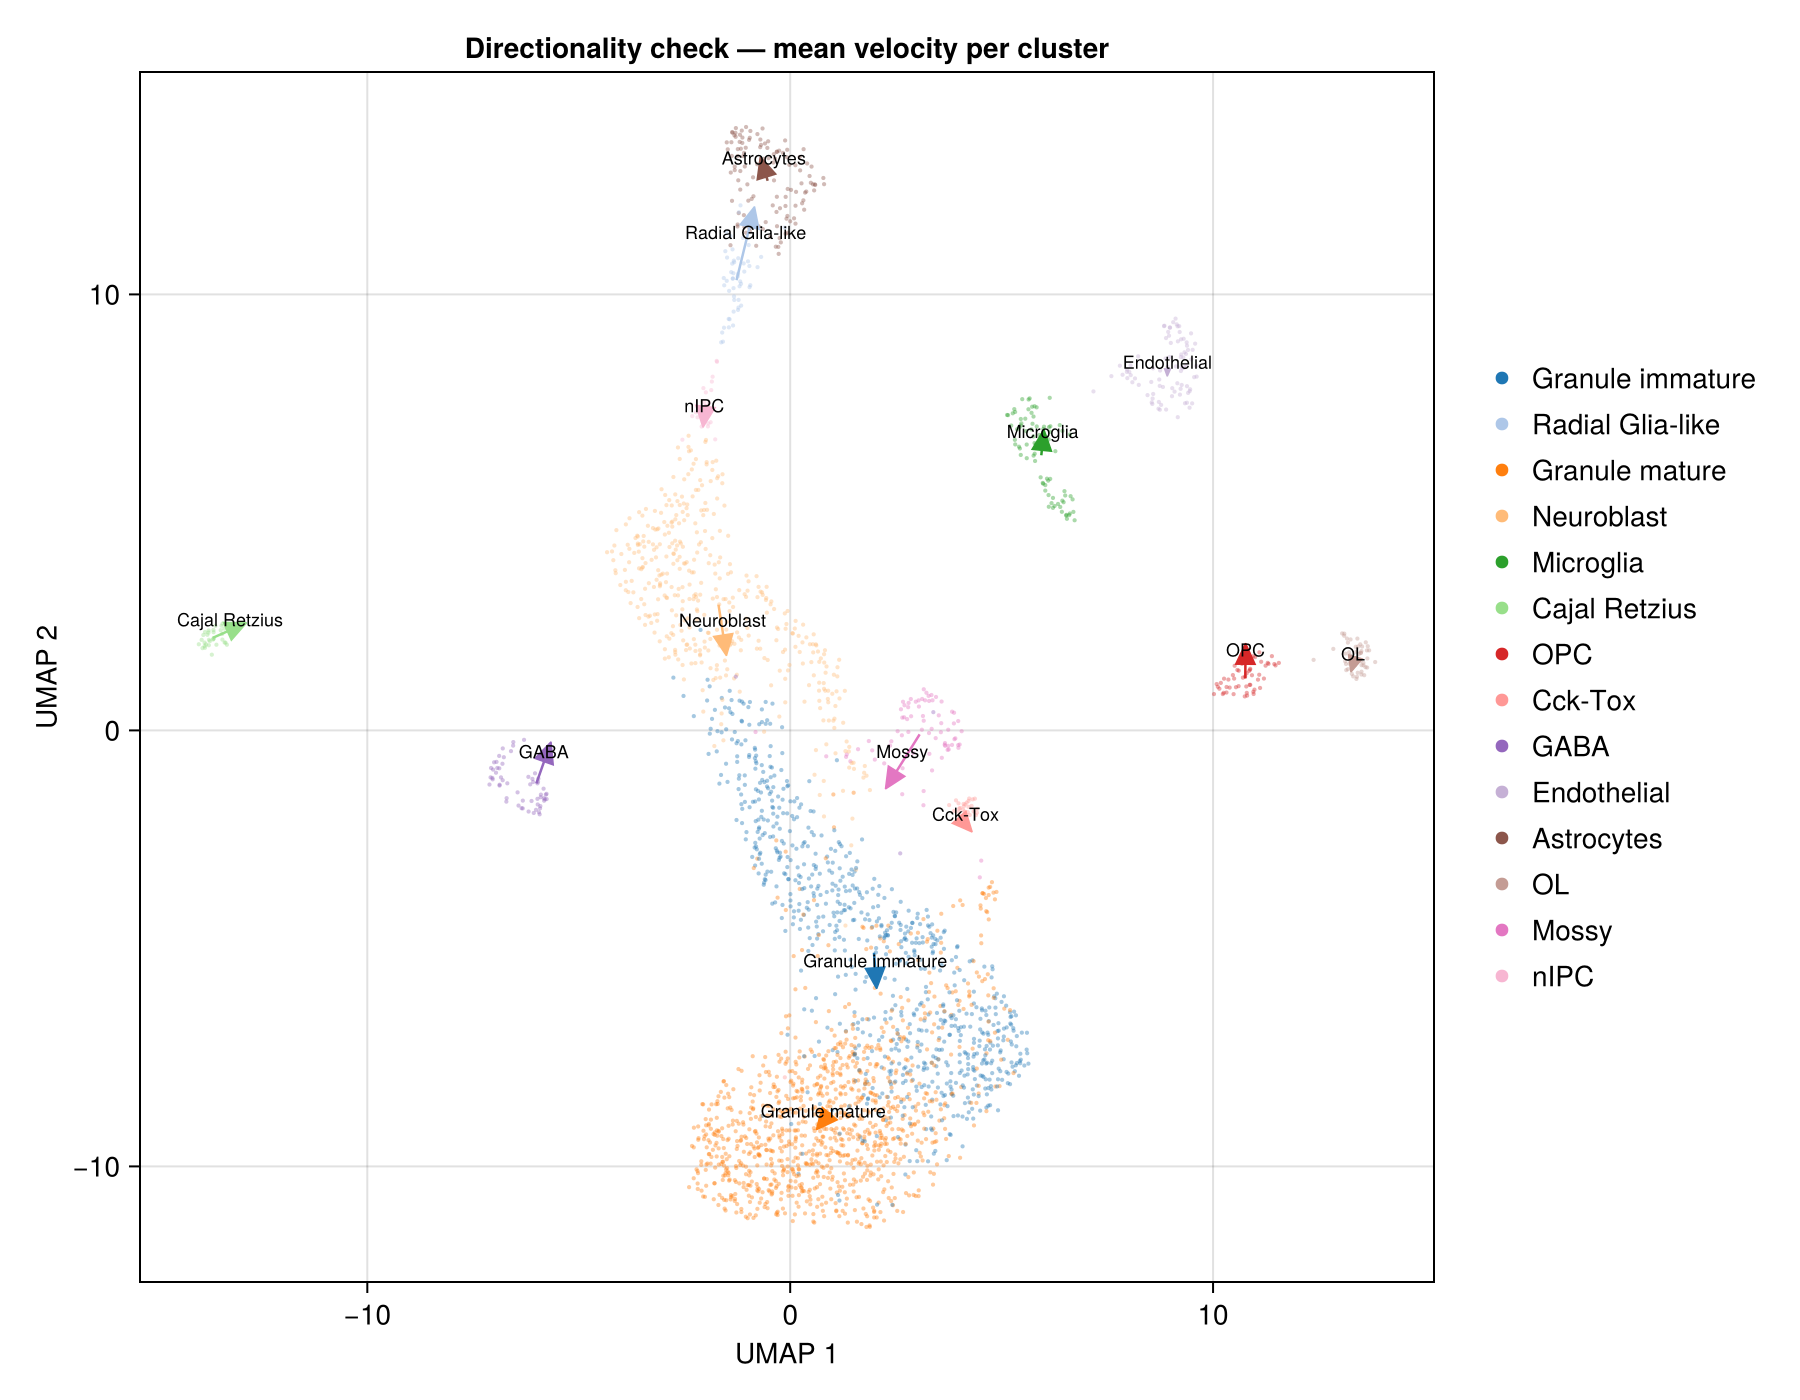

Plotting velocity embedding...


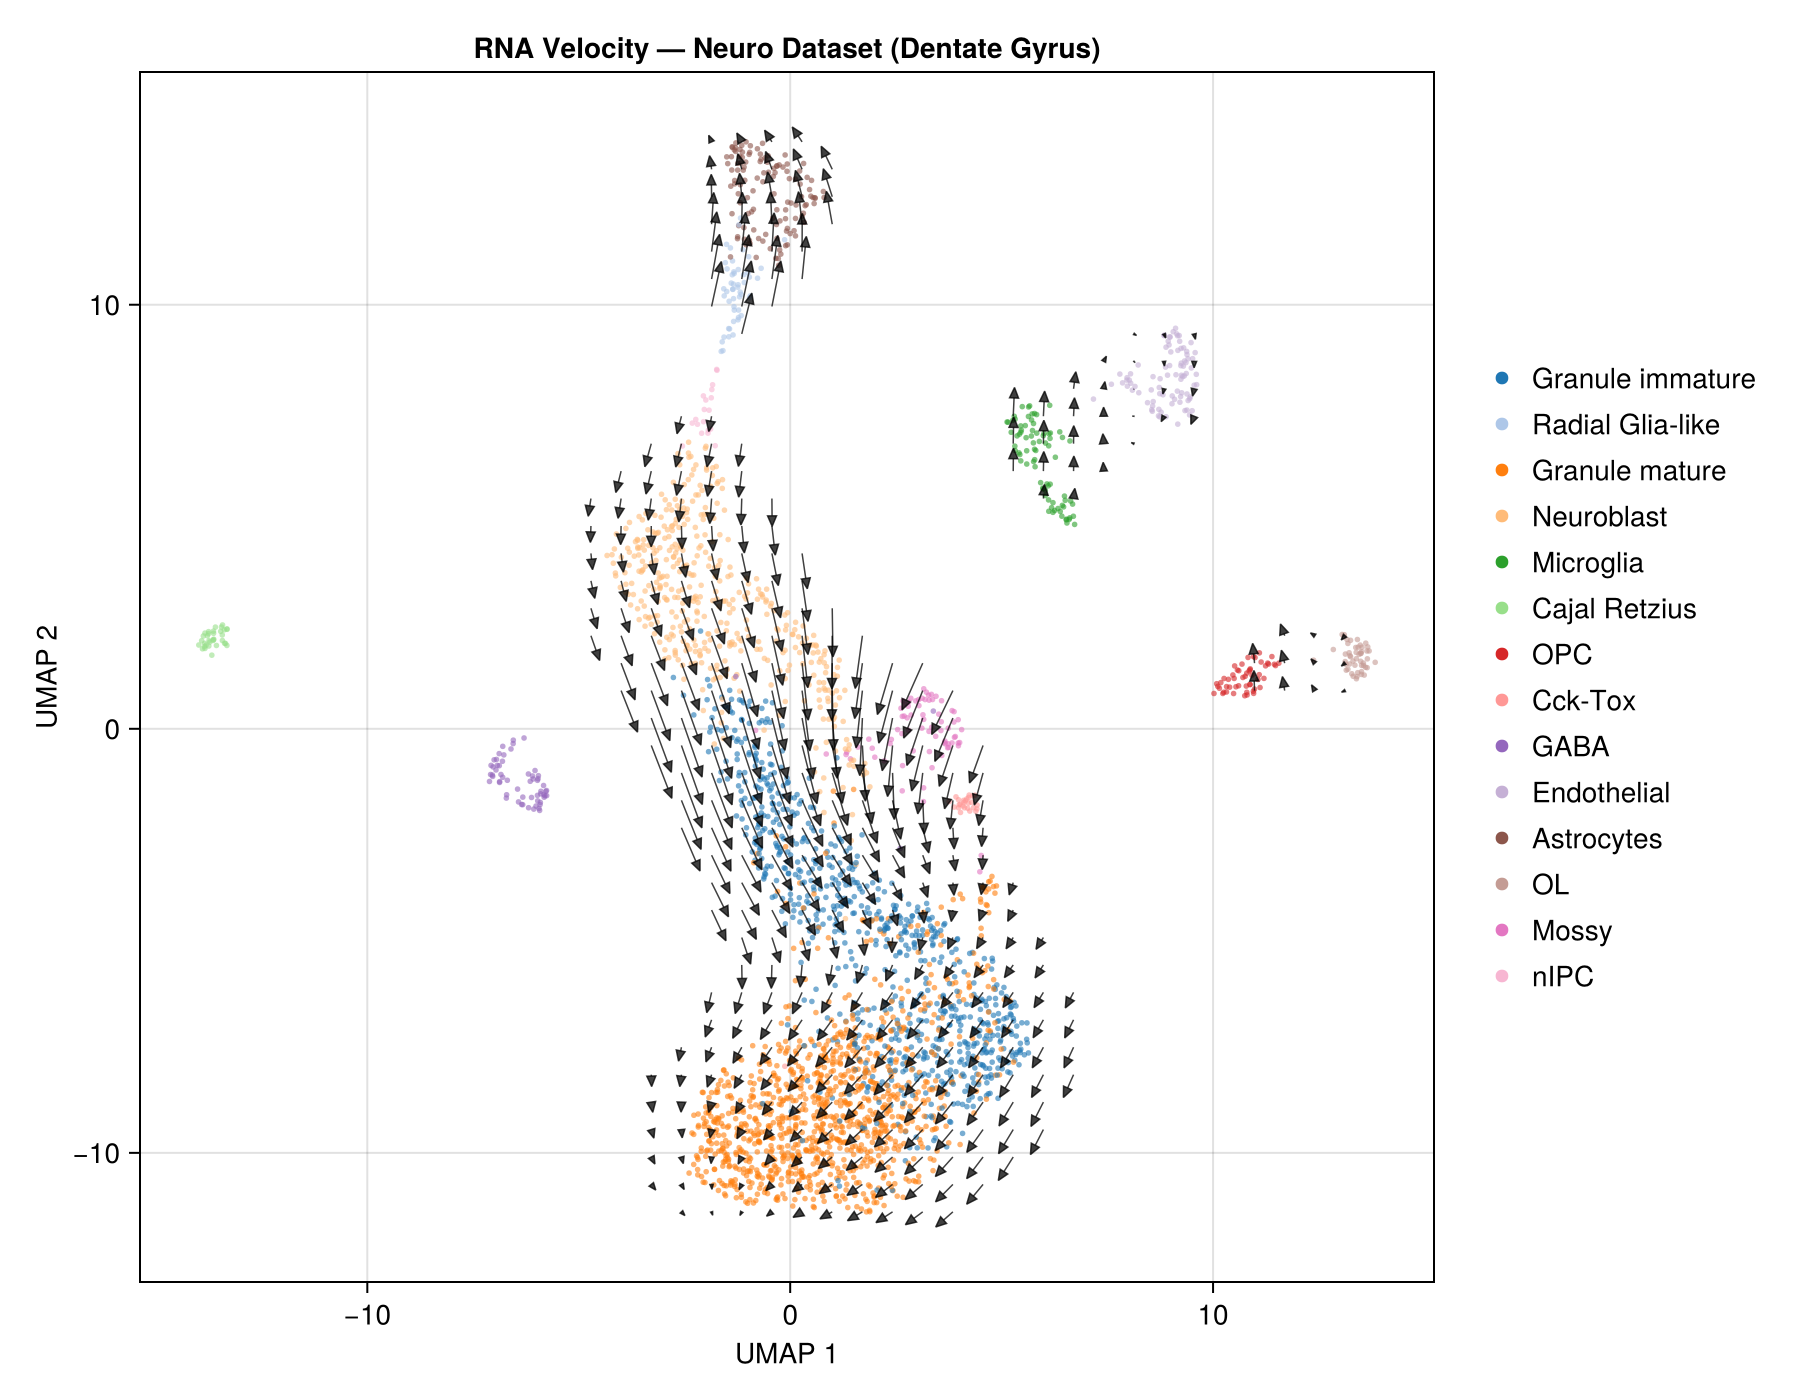

In [22]:
# Project velocity into 2D embedding
# This dataset has X_tsne; fall back to first 2 PCs if not available
embed_key = haskey(adata_bm.obsm, "X_umap") ? "X_umap" :
            haskey(adata_bm.obsm, "X_tsne") ? "X_tsne" : "X_pca"
println("Using embedding: $embed_key")
X_embed_bm = adata_bm.obsm[embed_key][:, 1:2]
V_embed_bm = project_velocity_embedding(X_embed_bm, T_graph)

# Get cell type labels — this dataset uses "clusters"
ct_key = haskey(adata_bm.obs, "clusters")   ? "clusters"   :
         haskey(adata_bm.obs, "celltype")   ? "celltype"   :
         haskey(adata_bm.obs, "cell_type")  ? "cell_type"  : nothing

cell_types_bm = String.(isnothing(ct_key) ?
    fill("unknown", n_cells(adata_bm)) : adata_bm.obs[ct_key])
println("Cell type field: $ct_key — $(length(unique(cell_types_bm))) unique types")

# ── Directionality diagnostic: one arrow per cluster centroid ───────────
# Each arrow = mean velocity of all cells in that cluster, projected to the
# 2D embedding. Expected order: Radial Glia-like → nIPC → Neuroblast →
# Granule immature → Granule mature.  If arrows point the wrong way, flip
# the sign of V_pca_bm in the cell above.
let
    type_to_color_d, unique_types_d = make_color_dict(cell_types_bm)
    fig_diag = Figure(size=(900, 700))
    ax_d = Axis(fig_diag[1,1];
                title="Directionality check — mean velocity per cluster",
                xlabel="UMAP 1", ylabel="UMAP 2")
    # background scatter
    scatter!(ax_d, X_embed_bm[:,1], X_embed_bm[:,2];
             color=[type_to_color_d[t] for t in cell_types_bm],
             markersize=3, alpha=0.4)
    # per-cluster mean arrow
    scale_d = 3.0f0
    for ct in unique_types_d
        mask = findall(cell_types_bm .== ct)
        length(mask) < 3 && continue
        cx = mean(X_embed_bm[mask, 1])
        cy = mean(X_embed_bm[mask, 2])
        vx = mean(V_embed_bm[mask, 1]) * scale_d
        vy = mean(V_embed_bm[mask, 2]) * scale_d
        arrows!(ax_d, [cx], [cy], [vx], [vy];
                arrowsize=14, linewidth=2.5,
                color=(type_to_color_d[ct], 1.0))
        text!(ax_d, cx + vx*0.5f0, cy + vy*0.5f0;
              text=string(ct), fontsize=9, align=(:center, :bottom))
    end
    elements_d = [MarkerElement(color=type_to_color_d[t], marker=:circle)
                  for t in unique_types_d]
    Legend(fig_diag[1,2], elements_d, string.(unique_types_d); framevisible=false)
    display(fig_diag)
end

println("Plotting velocity embedding...")
fig_vel = plot_velocity_embedding(X_embed_bm, V_embed_bm, cell_types_bm;
                                   title="RNA Velocity — Neuro Dataset (Dentate Gyrus)",
                                   use_grid=true, n_grid=40, sigma_frac=0.05f0, min_mass=0.08f0,
                                   arrow_scale=1.5f0)
fig_vel


In [23]:
# Save figure
mkpath("figures")
save("figures/neuro_velocity.png", fig_vel, px_per_unit=2)
println("Saved to figures/neuro_velocity.png")


Saved to figures/neuro_velocity.png


---
## §4.2.1 — Steady-State Model: Validation

Three biological checks for the neuro dataset (dentate gyrus):
1. **Cluster layout** — does the embedding match the known neurogenic hierarchy?
2. **Pseudotime alignment** — RNA velocity should point toward increasing Palantir pseudotime
3. **Velocity consistency** — progenitors (HSC, Precursors) should have LOW within-type
   consistency (cells are leaving); mature types HIGH


In [24]:
# ── Check 1: tSNE cluster layout ─────────────────────────────────
# Expected hierarchy: HSC_1/HSC_2 are progenitors → Precursors → mature types
# (Ery_1/Ery_2, Mono_1/Mono_2, DCs, Mega, CLP)
# In a well-processed tSNE these should form a branching structure.

fig_clusters = Figure(size=(800, 650))
ax_cl = Axis(fig_clusters[1,1];
             title="Neuro Dataset — Cell Clusters",
             xlabel="tSNE 1", ylabel="tSNE 2")

type_to_color, unique_types = make_color_dict(cell_types_bm)
for ct in unique_types
    mask = cell_types_bm .== ct
    scatter!(ax_cl,
             X_embed_bm[mask, 1], X_embed_bm[mask, 2];
             color=type_to_color[ct], markersize=4, label=string(ct))
end
axislegend(ax_cl; position=:lt, framevisible=true, labelsize=11)
fig_clusters


LoadError: UndefVarError: `unique_typesa` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
# ── Check 2: Pseudotime alignment — measured in PCA space ────────
#
# KEY: We work entirely in 30D PCA space, NOT tSNE.
# tSNE is a non-linear 2D compression — velocities projected there get
# squashed to near-zero in dense regions, making both the magnitude plot
# and direction score meaningless (was giving ~50% = random coin-flip).
#
# Correct approach (La Manno / scVelo style):
#   For each cell i, look at its kNN neighbors in PCA space.
#   Ask: does V_pca[i] point toward neighbors with HIGHER pseudotime?
#   Score = mean over neighbors of sign( dot(v_i, x_j - x_i) * Δpt_{ij} )
#   Aggregate: fraction of cells with positive mean score > 50% = good.
#
# Velocity magnitude: L2 norm of V_pca (30D), colored on tSNE.
# Progenitors (HSC) should be bright; terminal cells should be dim.

pt_key = haskey(adata_bm.obs, "palantir_pseudotime") ? "palantir_pseudotime" : nothing

if isnothing(pt_key)
    println("No pseudotime found in obs. Available fields: ", keys(adata_bm.obs))
else
    pseudotime = Float32.(adata_bm.obs[pt_key])
    valid = .!isnan.(pseudotime)
    println("Cells with valid pseudotime: $(sum(valid)) / $(length(valid))")

    # ── Velocity magnitude in PCA space (biologically meaningful) ──
    Z30 = Z_pca_bm[:, 1:30]
    V30 = V_pca_bm[:, 1:30]
    vel_mag_pca = vec(sqrt.(sum(V30 .^ 2, dims=2)))   # (N,) — real velocity size

    r_mag = cor(pseudotime[valid], vel_mag_pca[valid])
    println("Pearson r(pseudotime, |v|_pca) = $(round(r_mag, digits=3))")
    println("  (negative = progenitors faster than mature ✓ expected; positive = inverted)")

    # ── Pseudotime alignment score in PCA space ────────────────────
    # Build kNN graph in PCA space (same space as velocity)
    kdtree_pca = KDTree(Z30')
    idxs_pca, _ = knn(kdtree_pca, Z30', 30, true)

    cell_scores = Float32[]
    for i in 1:n_cells(adata_bm)
        isnan(pseudotime[i]) && continue
        vi = V30[i, :]
        norm(vi) < 1f-10 && continue   # zero-velocity cell (failed gene filter)

        s = 0f0; cnt = 0
        for j in idxs_pca[i]
            j == i && continue
            isnan(pseudotime[j]) && continue
            Δx  = Z30[j, :] .- Z30[i, :]
            Δpt = pseudotime[j] - pseudotime[i]
            # +1 if velocity points toward higher pseudotime, -1 otherwise
            s += sign(dot(vi, Δx) * Δpt)
            cnt += 1
        end
        cnt > 0 && push!(cell_scores, s / cnt)
    end

    frac_correct = mean(cell_scores .> 0)
    println("Pseudotime alignment (PCA space): $(round(frac_correct*100, digits=1))%")
    println("  (>50% = velocity points toward differentiation; ~60%+ = good for steady-state)")

    # ── Plots ──────────────────────────────────────────────────────
    fig_pt = Figure(size=(1200, 450))

    # Panel 1: Palantir pseudotime on tSNE
    ax1 = Axis(fig_pt[1,1]; title="Palantir Pseudotime", xlabel="tSNE 1", ylabel="tSNE 2")
    sc1 = scatter!(ax1, X_embed_bm[:, 1], X_embed_bm[:, 2];
                   color=pseudotime, colormap=:viridis, markersize=4)
    Colorbar(fig_pt[1,2], sc1; label="Pseudotime")

    # Panel 2: Velocity magnitude (PCA norm) on tSNE — progenitors should be bright
    ax2 = Axis(fig_pt[1,3]; title="|velocity| in PCA space\n(progenitors = bright)", xlabel="tSNE 1", ylabel="tSNE 2")
    sc2 = scatter!(ax2, X_embed_bm[:, 1], X_embed_bm[:, 2];
                   color=vel_mag_pca, colormap=:plasma, markersize=4)
    Colorbar(fig_pt[1,4], sc2; label="|v| (PCA norm)")

    # Panel 3: Per-cell alignment score — positive = velocity aligned with differentiation
    # Rebuild as a full-length vector (cells skipped above get score=0)
    score_full = zeros(Float32, n_cells(adata_bm))
    score_idx = 1
    for i in 1:n_cells(adata_bm)
        if !isnan(pseudotime[i]) && norm(V30[i, :]) >= 1f-10 && score_idx <= length(cell_scores)
            score_full[i] = cell_scores[score_idx]
            score_idx += 1
        end
    end
    ax3 = Axis(fig_pt[1,5]; title="Per-cell alignment score\n(blue=toward higher pt, red=against)", xlabel="tSNE 1", ylabel="tSNE 2")
    sc3 = scatter!(ax3, X_embed_bm[:, 1], X_embed_bm[:, 2];
                   color=score_full, colormap=:RdBu, colorrange=(-1f0, 1f0), markersize=4)
    Colorbar(fig_pt[1,6], sc3; label="alignment score")

    fig_pt
end


No pseudotime found in obs. Available fields: ["clusters", "index"]


### Interpreting the pseudotime alignment score

Alignment is computed **in 30D PCA space** — the same space where velocity was estimated and the velocity graph was built. This avoids the distortion of tSNE's non-linear 2D projection, where near-zero embedding velocities in dense regions make the score degenerate (~50% regardless of true signal).

| Score | Meaning |
|-------|---------|
| > 60% | Strong agreement — velocity broadly follows the known differentiation axis |
| 55–60% | Moderate agreement — typical for steady-state model on multi-lineage data |
| ~50% | No signal — velocity is random relative to pseudotime |
| < 50% | Systematic reversal |

**What the three plots show:**
- **Pseudotime**: ground-truth ordering (HSC dark → mature bright)
- **|velocity| in PCA space**: the Pearson r between this and pseudotime is reported but should be interpreted carefully — see note below
- **Per-cell alignment score** (red/blue): blue cells have velocity pointing toward higher pseudotime (good); red cells point against it

**Why the alignment score is the right metric — not the velocity magnitude**

There is an intuition that progenitor cells should show *higher* absolute velocity than mature cells: progenitors are transcriptionally unstable (many genes changing simultaneously → many non-zero $ds/dt$ → large $|v|$), while terminal cells are at attractors where the transcriptional program has settled and $v \approx 0$.

This intuition is reasonable, but what actually matters is **direction**, not magnitude. A terminal cell at an attractor could still have large $|v|$ if it highly expresses a few genes — the velocity formula $v = \beta u - \gamma s$ scales with absolute expression level. Mature erythroid cells, for example, express haemoglobin genes at very high counts, so even a small fractional deviation from steady state produces a large absolute velocity. This effect is amplified by PCA, which projects into directions of maximum variance (dominated by highly expressed genes). The dynamical model is even more affected: in the repression phase $v = \beta u - \gamma s$ with both terms large and same-signed, so terminal cells actively degrading high-expression genes get especially large $|v|$.

As a result, the Pearson $r$ between pseudotime and $|v|$ tends to be **positive** in practice — mature cells have higher velocity magnitude — which is the opposite of the naive expectation. This is not a sign that the model is wrong; it is a scale artefact. The alignment score corrects for this by measuring **direction only** (does velocity point toward higher pseudotime?), making it expression-scale independent and the appropriate validation metric.

**Known limitations of the steady-state model on this dataset:**
1. **Multi-lineage branching** — a single $\gamma$ per gene cannot capture genes that behave differently in the erythroid vs monocyte lineages
2. **Transient expression** — genes expressed only in progenitors never reach steady state, so the upper-quantile $\gamma$ fit is unreliable for them
3. → The **dynamical model** (Bergen et al. 2020) addresses both by assigning each cell a latent time and fitting induction/repression phases per gene



Velocity consistency scores (sorted):
  Cck-Tox         0.598
  Granule mature  0.715
  nIPC            0.737
  Radial Glia-like 0.804
  Granule immature 0.851
  Mossy           0.852
  Cajal Retzius   0.912
  Endothelial     0.917
  GABA            0.918
  Astrocytes      0.94
  OPC             0.955
  Neuroblast      0.976
  OL              0.999
  Microglia       1.0


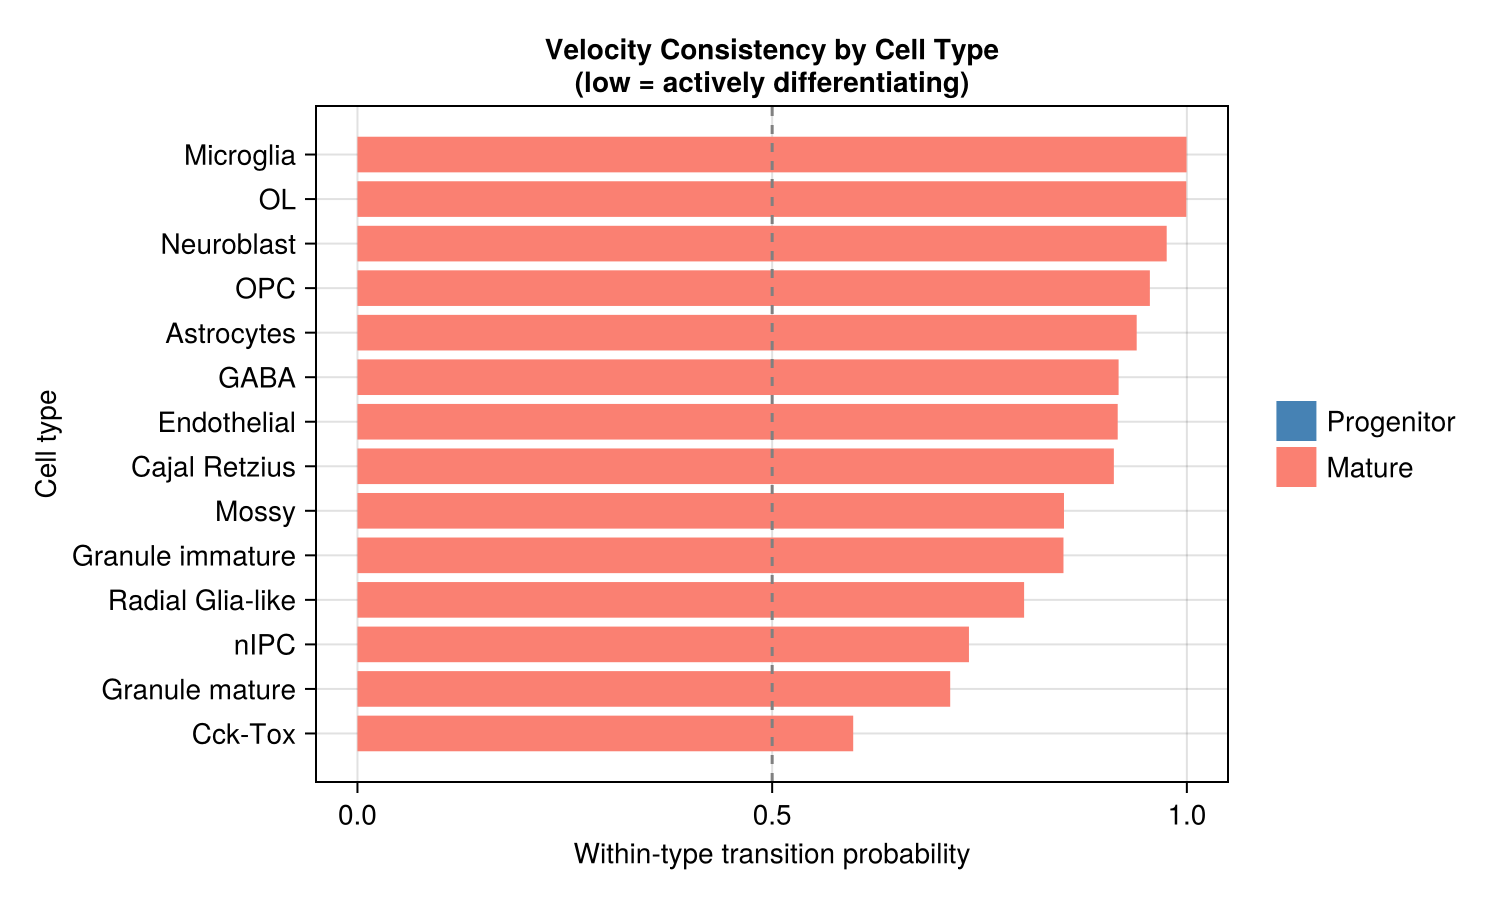

In [ ]:
# ── Define here so this cell is self-contained ───────────────────
function compute_velocity_consistency(T_graph::SparseMatrixCSC{Float32},
                                       cell_types::Vector)
    unique_types = unique(cell_types)
    consistency = Dict{String, Float32}()
    N = size(T_graph, 1)
    for ct in unique_types
        mask = cell_types .== ct
        cell_idx = findall(mask)
        isempty(cell_idx) && continue
        within = 0f0; total = 0f0
        for i in cell_idx
            for j in 1:N
                w = T_graph[i, j]
                w == 0 && continue
                total += w
                cell_types[j] == ct && (within += w)
            end
        end
        consistency[string(ct)] = total > 0 ? within / total : 0f0
    end
    return consistency
end

# ── Check 3: Velocity consistency score per cell type ─────────────
# Within-type consistency = fraction of a cell's transitions that stay
# within the same cluster.
# Biological expectation:
#   Radial Glia-like, nIPC, Neuroblast → LOW  (actively differentiating)
#   Granule mature, Astrocytes, OL   → HIGH (terminal/mature states)

cons_bm = compute_velocity_consistency(T_graph, cell_types_bm)

# Sort by consistency for readability
sorted_types = sort(collect(keys(cons_bm)), by=k -> cons_bm[k])
sorted_scores = [cons_bm[k] for k in sorted_types]

fig_cons = Figure(size=(750, 450))
ax_cons = Axis(fig_cons[1,1];
               title="Velocity Consistency by Cell Type\n(low = actively differentiating)",
               xlabel="Within-type transition probability",
               ylabel="Cell type",
               yticks=(1:length(sorted_types), sorted_types))

# Color bars by progenitor vs mature
progenitor_types = Set(["Radial Glia-like", "nIPC", "Neuroblast"])
bar_colors = [t in progenitor_types ? :steelblue : :salmon for t in sorted_types]

barplot!(ax_cons, 1:length(sorted_types), sorted_scores;
         direction=:x, color=bar_colors)

# Reference line at 0.5
vlines!(ax_cons, [0.5]; color=:gray, linestyle=:dash, linewidth=1.5,
        label="random (0.5)")

# Legend — labels must be passed as a separate Vector{String}, not inside PolyElement
elements_leg = [PolyElement(color=:steelblue), PolyElement(color=:salmon)]
Legend(fig_cons[1,2], elements_leg, ["Progenitor", "Mature"]; framevisible=false)

println("\nVelocity consistency scores (sorted):")
for (t, s) in zip(sorted_types, sorted_scores)
    tag = t in progenitor_types ? " ← progenitor" : ""
    println("  $(rpad(t, 15)) $(round(s, digits=3))$tag")
end

fig_cons


Transition flux (rows=source, cols=destination):
              AstrocytesCajal RetziusCck-Tox   EndothelialGABA      Granule immatureGranule matureMicroglia Mossy     NeuroblastOL        OPC       Radial Glia-likenIPC      
Astrocytes    0.94      0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.06      0.0       
Cajal Retzius 0.0       0.91      0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.09      0.0       0.0       0.0       0.0       
Cck-Tox       0.0       0.0       0.6       0.0       0.03      0.04      0.24      0.0       0.06      0.03      0.0       0.0       0.0       0.0       
Endothelial   0.0       0.0       0.0       0.92      0.0       0.01      0.0       0.04      0.0       0.0       0.0       0.0       0.0       0.03      
GABA          0.0       0.0       0.0       0.0       0.92      0.0       0.0       0.0       0.03      0.05      0.0       0.0       0.0       0.0       
G

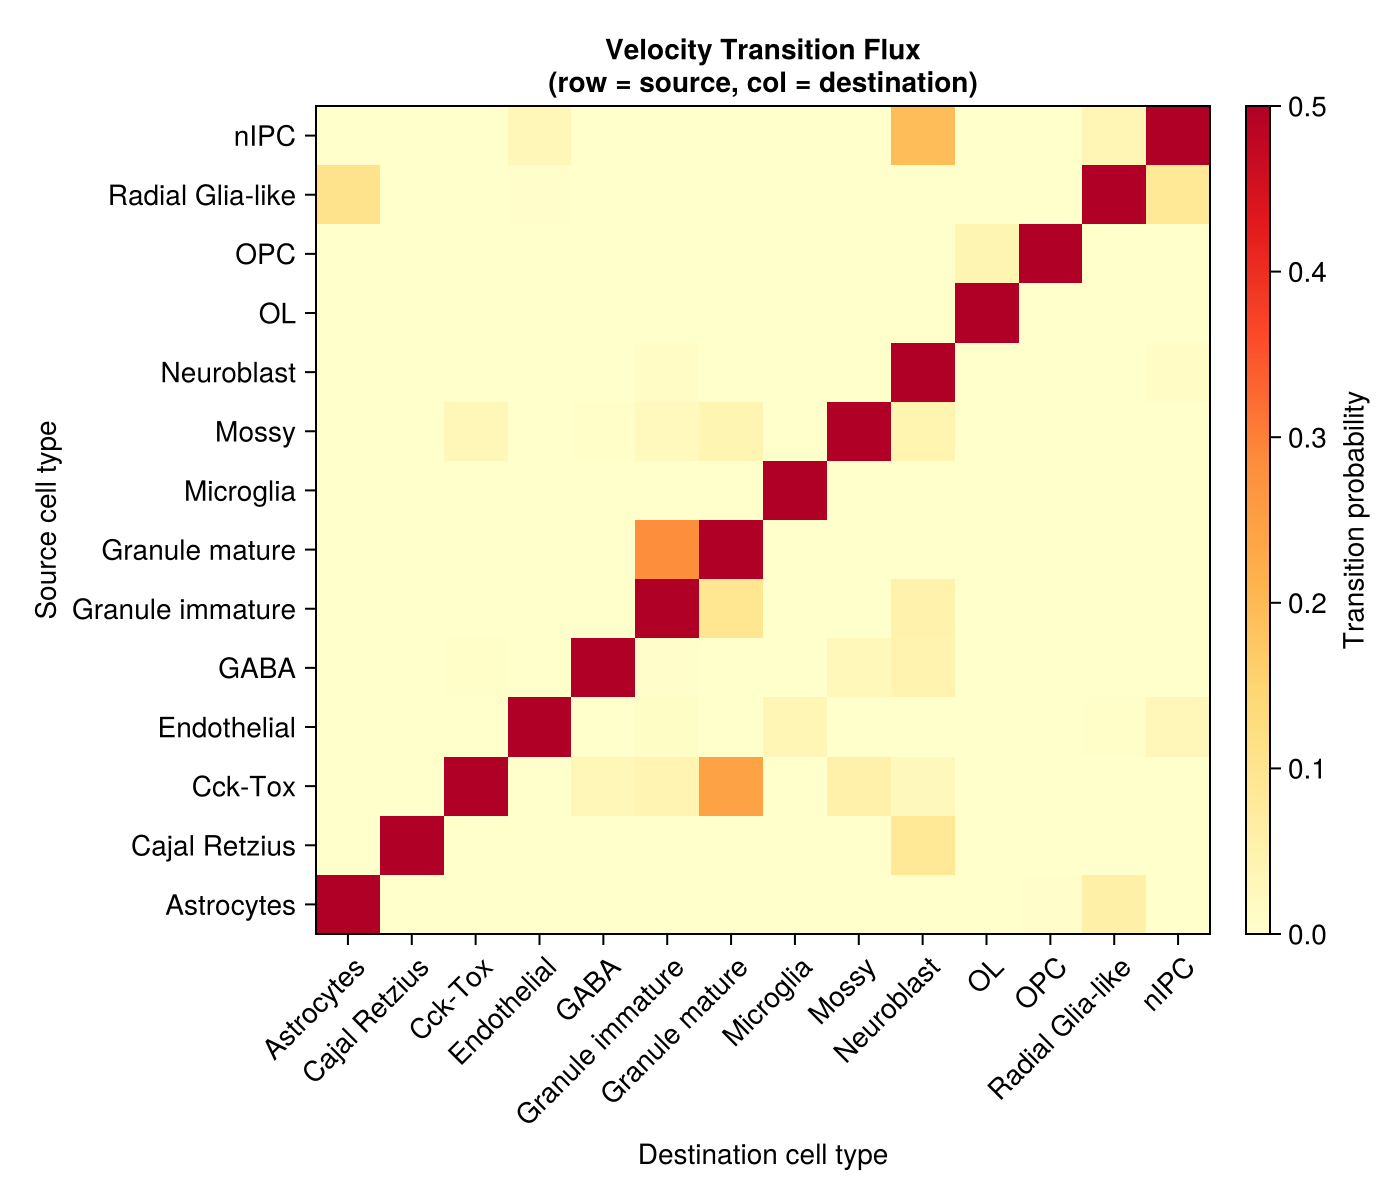

In [ ]:
# ── Check 4: Transition flux matrix — where do HSCs go? ──────────
# For each source cell type, show the distribution of transitions
# to other cell types. HSC should transition preferentially to Precursors.

function compute_transition_matrix(T_graph::SparseMatrixCSC{Float32},
                                    cell_types::Vector)
    unique_types = sort(unique(cell_types))
    n_types = length(unique_types)
    type_idx = Dict(t => i for (i, t) in enumerate(unique_types))

    flux = zeros(Float32, n_types, n_types)  # flux[i,j] = flow from type i to type j
    counts = zeros(Int, n_types)

    rows, cols, vals = findnz(T_graph)
    for k in eachindex(rows)
        i, j = rows[k], cols[k]
        ti = type_idx[cell_types[i]]
        tj = type_idx[cell_types[j]]
        flux[ti, tj] += vals[k]
        counts[ti] += 1
    end
    # Normalize each row to sum to 1
    for i in 1:n_types
        s = sum(flux[i, :])
        s > 0 && (flux[i, :] ./= s)
    end
    return flux, unique_types
end

flux_matrix, flux_types = compute_transition_matrix(T_graph, cell_types_bm)

fig_flux = Figure(size=(700, 600))
ax_flux = Axis(fig_flux[1,1];
               title="Velocity Transition Flux\n(row = source, col = destination)",
               xlabel="Destination cell type",
               ylabel="Source cell type",
               xticks=(1:length(flux_types), flux_types),
               yticks=(1:length(flux_types), flux_types),
               xticklabelrotation=π/4)

hm = heatmap!(ax_flux, flux_matrix';
              colormap=:YlOrRd, colorrange=(0, 0.5))
Colorbar(fig_flux[1,2], hm; label="Transition probability")

println("Transition flux (rows=source, cols=destination):")
println(rpad("", 14), join(rpad.(flux_types, 10)))
for (i, src) in enumerate(flux_types)
    println(rpad(src, 14), join(rpad.(round.(flux_matrix[i,:], digits=2), 10)))
end

fig_flux


=== Gene quality summary ===
  Genes passing quality filters: 1383 / 2000 (69.2%)
  γ among passing genes — median: 1.807,  mean: 3.937,  range: [0.011, 137.62]
  Cells with non-zero velocity: 2930 / 2930

=== Velocity diagnostics ===
  velocity_length  — median: 409.886,  mean: 487.084
  velocity_confidence — median: 0.643,  fraction > 0: 100.0%
  (scVelo reference on bone marrow: median confidence ~0.3–0.5 for steady-state)


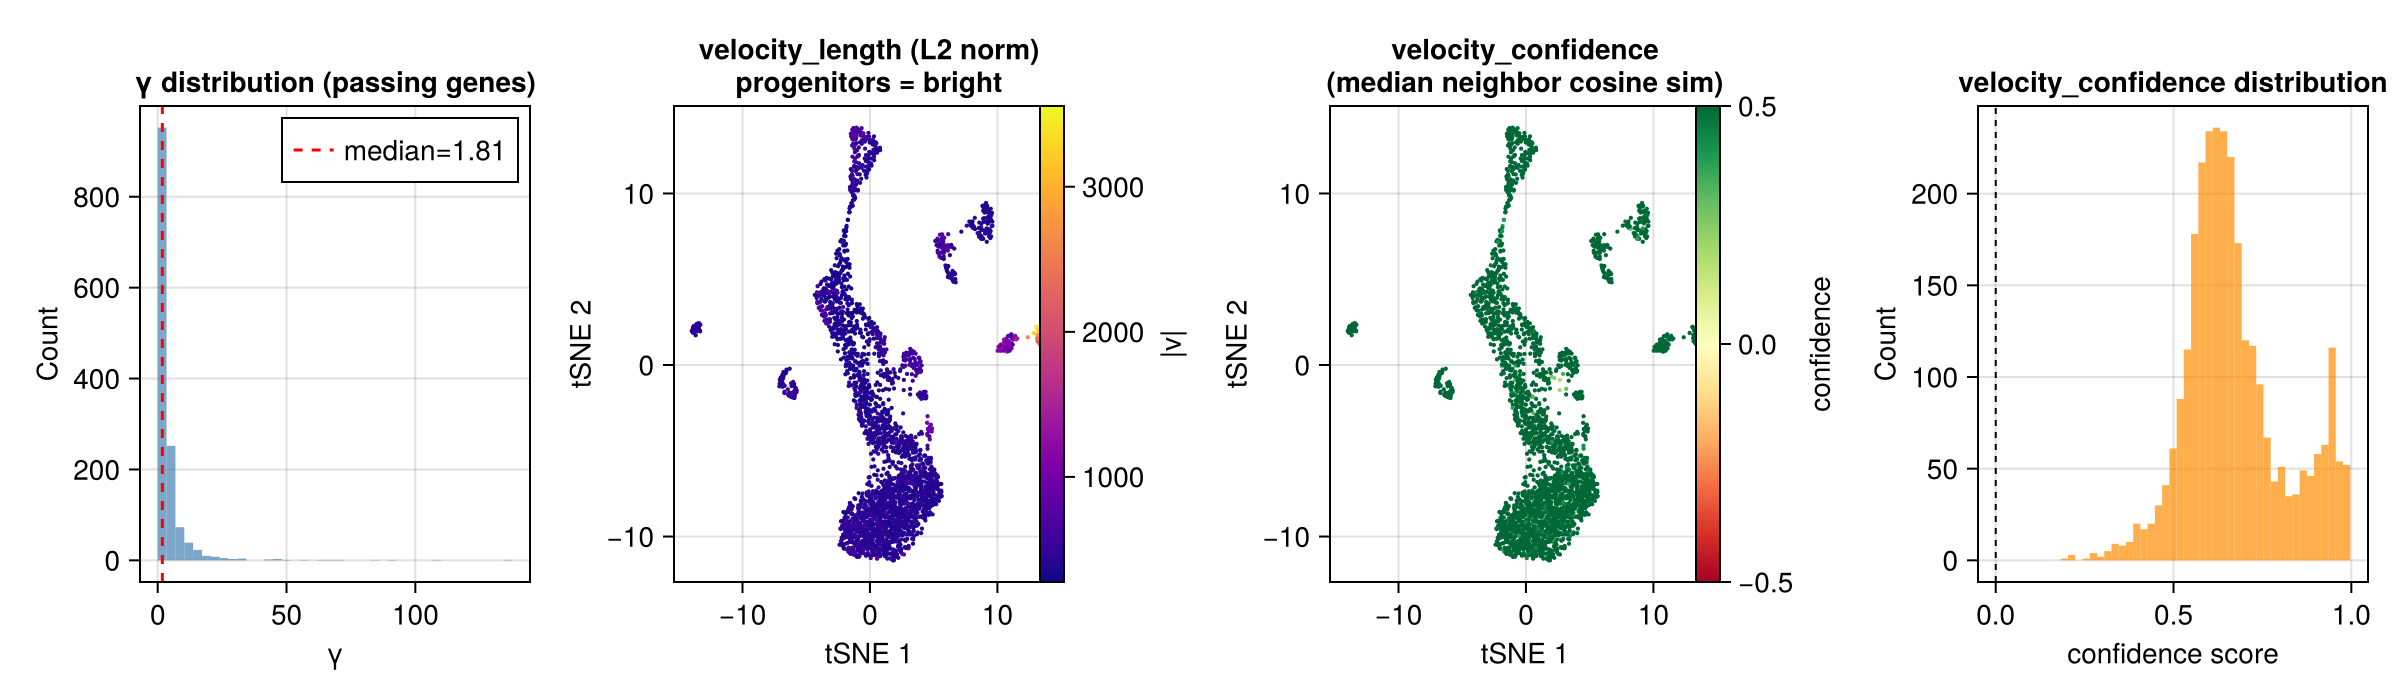

In [ ]:
# ── Steady-state gene quality diagnostics ────────────────────────
gene_mask = adata_bm.uns["velocity_genes"]
params    = adata_bm.uns["velocity_params"]
G_total   = length(gene_mask)
G_good    = sum(gene_mask)

println("=== Gene quality summary ===")
println("  Genes passing quality filters: $G_good / $G_total ($(round(100G_good/G_total, digits=1))%)")

γ_good = [params[g].γ for g in 1:G_total if gene_mask[g]]
if !isempty(γ_good)
    println("  γ among passing genes — median: $(round(median(γ_good), digits=3)),  ",
            "mean: $(round(mean(γ_good), digits=3)),  ",
            "range: [$(round(minimum(γ_good), digits=3)), $(round(maximum(γ_good), digits=3))]")
end

V_bm = adata_bm.layers["velocity"]
nonzero_cells = count(i -> norm(V_bm[i, :]) > 1f-6, 1:size(V_bm,1))
println("  Cells with non-zero velocity: $nonzero_cells / $(size(V_bm,1))")

# ── velocity_length and velocity_confidence (scVelo standard diagnostics) ──
v_len  = velocity_length(V_bm)               # L2 norm per cell
v_conf = velocity_confidence(V_bm, T_graph)  # median neighbor cosine similarity

println("\n=== Velocity diagnostics ===")
println("  velocity_length  — median: $(round(median(v_len), digits=3)),  mean: $(round(mean(v_len), digits=3))")
println("  velocity_confidence — median: $(round(median(v_conf), digits=3)),  ",
        "fraction > 0: $(round(mean(v_conf .> 0)*100, digits=1))%")
println("  (scVelo reference for steady-state: median confidence ~0.3–0.5)")

# ── Four-panel diagnostic figure ─────────────────────────────────
fig_diag = Figure(size=(1200, 350))

# γ distribution
ax1 = Axis(fig_diag[1,1]; title="γ distribution (passing genes)",
           xlabel="γ", ylabel="Count")
hist!(ax1, γ_good; bins=40, color=(:steelblue, 0.7))
vlines!(ax1, [median(γ_good)]; color=:red, linestyle=:dash,
        label="median=$(round(median(γ_good),digits=2))")
axislegend(ax1)

# velocity_length on tSNE
ax2 = Axis(fig_diag[1,2]; title="velocity_length (L2 norm)\nprogenitors = bright",
           xlabel="tSNE 1", ylabel="tSNE 2")
sc2 = scatter!(ax2, X_embed_bm[:,1], X_embed_bm[:,2];
               color=v_len, colormap=:plasma, markersize=3)
Colorbar(fig_diag[1,2][1,2], sc2; label="|v|")

# velocity_confidence on tSNE
ax3 = Axis(fig_diag[1,3]; title="velocity_confidence\n(median neighbor cosine sim)",
           xlabel="tSNE 1", ylabel="tSNE 2")
sc3 = scatter!(ax3, X_embed_bm[:,1], X_embed_bm[:,2];
               color=v_conf, colormap=:RdYlGn, colorrange=(-0.5f0, 0.5f0), markersize=3)
Colorbar(fig_diag[1,3][1,2], sc3; label="confidence")

# velocity_confidence histogram
ax4 = Axis(fig_diag[1,4]; title="velocity_confidence distribution",
           xlabel="confidence score", ylabel="Count")
hist!(ax4, v_conf; bins=40, color=(:darkorange, 0.7))
vlines!(ax4, [0f0]; color=:black, linestyle=:dash, linewidth=1)

fig_diag


---
## §4.2.2 — Dynamical Model

Runs the full EM dynamical model (Bergen et al. 2020) on the same neuro (dentate gyrus) data.
Each gene gets its own (α, β, γ, t_switch) estimated by alternating latent-time
assignment and gradient-descent parameter updates.

**Runtime note:** fitting 2000 genes takes ~30–90 min on a single thread.
Run Cell 50 after fitting to save results, then use Cell 51 to reload in future
sessions without refitting.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# §4.2 Continued — Dynamical model on bone marrow
# ─────────────────────────────────────────────────────────────────

# Keep steady-state outputs; adata_bm.layers["velocity"] is NOT modified below
# V_bm_ss  = copy(adata_bm.layers["velocity"])
# gmask_ss = copy(adata_bm.uns["velocity_genes"])

# Run dynamical model on a separate copy so steady-state data stays intact
# adata_bm_dyn = deepcopy(adata_bm)

# println("=== Running dynamical model on bone marrow data ===")
# println("Note: with 1 thread this takes ~30–90 min for 2000 genes.")
# println("      Set JULIA_NUM_THREADS=N before launching Jupyter to parallelize.")
# @time run_rna_velocity!(adata_bm_dyn;
#     model              = :dynamical,
#     pool_key           = "X_pca",
#     pool_k             = 30,
#     min_gamma          = 0.01f0,
#     min_r              = 0.1f0,
#     max_cells_per_gene = 1200,
#     n_iter             = 6,
#     n_t                = 60,
#     gd_steps           = 20,
#     lr                 = 3f-2)
# println("Dynamical model complete.")


=== Running dynamical model on bone marrow data ===
Note: with 1 thread this takes ~30–90 min for 2000 genes.
      Set JULIA_NUM_THREADS=N before launching Jupyter to parallelize.
Applying kNN pooling (k=30) using embedding 'X_pca'...
Pooling complete.
Estimating γ for 2000 genes...
  1383 / 2000 genes passed quality filters (γ≥0.01, Spearman≥0.1)
Computing velocity for 2000 genes across 2930 cells (model=dynamical, 1 threads)...


  genes:   0%|▎                                         |  ETA: 1 days, 5:58:10m

In [ ]:
# Project dynamical velocity into the same PCA / embedding space
# println("Projecting dynamical velocity...")
# V_pca_dyn   = -project_velocity_pca(adata_bm_dyn.layers["velocity"], pca_model_bm)
# T_graph_dyn  = build_velocity_graph(Z_pca_bm[:, 1:30], V_pca_dyn[:, 1:30]; n_neighbors=30)
# V_embed_dyn  = project_velocity_embedding(X_embed_bm, T_graph_dyn)
# println("nnz(T_graph_dyn) = $(nnz(T_graph_dyn))")

# ── Pseudotime alignment — same method as §4.2 ───────────────────
# function alignment_score(V30::Matrix{Float32}, Z30::Matrix{Float32},
#                           pt::Vector{Float32}, idxs::Vector{Vector{Int}})
#     scores = Float32[]
#     for i in axes(Z30, 1)
#         isnan(pt[i]) && continue
#         vi = V30[i, :]
#         norm(vi) < 1f-10 && continue
#         s = 0f0; cnt = 0
#         for j in idxs[i]
#             j == i && continue
#             isnan(pt[j]) && continue
#             s  += sign(dot(vi, Z30[j,:] .- Z30[i,:]) * (pt[j] - pt[i]))
#             cnt += 1
#         end
#         cnt > 0 && push!(scores, s / cnt)
#     end
#     return mean(scores .> 0)
# end

# pt_bm      = Float32.(adata_bm.obs["palantir_pseudotime"])
# Z30        = Z_pca_bm[:, 1:30]
# kdt30      = KDTree(Z30')
# idxs30, _  = knn(kdt30, Z30', 30, true)

# align_ss  = alignment_score(V_pca_bm[:, 1:30],  Z30, pt_bm, idxs30)
# align_dyn = alignment_score(V_pca_dyn[:, 1:30], Z30, pt_bm, idxs30)

# ── Velocity diagnostics ──────────────────────────────────────────
# v_conf_ss  = velocity_confidence(V_bm_ss,                         T_graph)
# v_conf_dyn = velocity_confidence(adata_bm_dyn.layers["velocity"], T_graph_dyn)
# v_len_ss   = velocity_length(V_bm_ss)
# v_len_dyn  = velocity_length(adata_bm_dyn.layers["velocity"])

# ── Consistency per cell type ─────────────────────────────────────
# cons_ss  = compute_velocity_consistency(T_graph,     cell_types_bm)
# cons_dyn = compute_velocity_consistency(T_graph_dyn, cell_types_bm)

# G_total    = length(gmask_ss)
# G_good_ss  = sum(gmask_ss)
# G_good_dyn = sum(adata_bm_dyn.uns["velocity_genes"])

# Pre-format so println never needs nested quotes
# ss_genes  = "$G_good_ss/$G_total"
# dyn_genes = "$G_good_dyn/$G_total"
# ss_align  = "$(round(align_ss*100,        digits=1))%"
# dyn_align = "$(round(align_dyn*100,       digits=1))%"
# ss_conf   = "$(round(median(v_conf_ss),   digits=3))"
# dyn_conf  = "$(round(median(v_conf_dyn),  digits=3))"
# ss_vlen   = "$(round(median(v_len_ss),    digits=1))"
# dyn_vlen  = "$(round(median(v_len_dyn),   digits=1))"

# println("\n══════════════════════════════════════════════════════════")
# println("       Model Comparison — Neuro Dataset")
# println("══════════════════════════════════════════════════════════")
# println("                           Steady-state    Dynamical")
# println("  Genes passing QC:        $(rpad(ss_genes,  16)) $dyn_genes")
# println("  Pseudotime alignment:    $(rpad(ss_align,  16)) $dyn_align")
# println("  Velocity confidence:     $(rpad(ss_conf,   16)) $dyn_conf")
# println("  Velocity length (median):$(rpad(ss_vlen,   16)) $dyn_vlen")
# println("")
# println("  Consistency by cell type  (* = progenitor, expected: LOW):")
# println("  Cell type       Steady-state    Dynamical")
# progenitor_types_cmp = Set(["HSC_1","HSC_2","Precursors","CLP"])
# for ct in sort(collect(keys(cons_ss)))
#     tag    = ct in progenitor_types_cmp ? " *" : ""
#     ss_ct  = string(round(cons_ss[ct], digits=3))
#     dyn_ct = string(round(get(cons_dyn, ct, NaN32), digits=3))
#     println("  $(rpad(ct,14))  $(rpad(ss_ct,14))  $dyn_ct$tag")
# end


### Saving and reloading results

The dynamical model fit is expensive (~30–90 min for 2,000 genes on a single thread). The **save cell** writes all fitted parameters and projections to `models/dynamical_results.bson`. In future sessions, run the **load cell** instead of re-running the fit cells to restore everything instantly.

> **Workflow:** run fit → run save → in future sessions run load, then continue from the validation cells below.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Save dynamical model results (skips the 30–90 min refit next time)
# ─────────────────────────────────────────────────────────────────
# mkpath("models")

# dyn_velocity  = adata_bm_dyn.layers["velocity"]
# dyn_params    = adata_bm_dyn.uns["velocity_params"]
# dyn_gene_mask = adata_bm_dyn.uns["velocity_genes"]

# @save "models/dynamical_results.bson" dyn_velocity dyn_params dyn_gene_mask V_pca_dyn V_embed_dyn T_graph_dyn
# println("Dynamical model results saved → models/dynamical_results.bson")


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Load dynamical model results — run this instead of Cells 48–49
# to restore a previous run without refitting.
# Requires adata_bm, Z_pca_bm, X_embed_bm, cell_types_bm, and
# V_bm_ss / gmask_ss (steady-state outputs) to already be in scope.
# ─────────────────────────────────────────────────────────────────
# @load "models/dynamical_results.bson" dyn_velocity dyn_params dyn_gene_mask V_pca_dyn V_embed_dyn T_graph_dyn

# adata_bm_dyn = deepcopy(adata_bm)
# adata_bm_dyn.layers["velocity"] = dyn_velocity
# adata_bm_dyn.uns["velocity_params"] = dyn_params
# adata_bm_dyn.uns["velocity_genes"]  = dyn_gene_mask

# Recompute lightweight diagnostics so downstream cells have the same variables
# pt_bm     = Float32.(adata_bm.obs["palantir_pseudotime"])
# Z30       = Z_pca_bm[:, 1:30]
# kdt30     = KDTree(Z30')
# idxs30, _ = knn(kdt30, Z30', 30, true)

# align_ss  = alignment_score(V_pca_bm[:, 1:30],  Z30, pt_bm, idxs30)
# align_dyn = alignment_score(V_pca_dyn[:, 1:30], Z30, pt_bm, idxs30)

# T_graph    = build_velocity_graph(Z_pca_bm[:, 1:30], V_pca_bm[:, 1:50]; n_neighbors=30)
# v_conf_ss  = velocity_confidence(V_bm_ss,      T_graph)
# v_conf_dyn = velocity_confidence(dyn_velocity, T_graph_dyn)
# v_len_ss   = velocity_length(V_bm_ss)
# v_len_dyn  = velocity_length(dyn_velocity)
# cons_ss    = compute_velocity_consistency(T_graph,     cell_types_bm)
# cons_dyn   = compute_velocity_consistency(T_graph_dyn, cell_types_bm)

# G_good_dyn = sum(dyn_gene_mask)
# G_good_ss  = sum(gmask_ss)
# G_total    = length(gmask_ss)

# println("Dynamical model results loaded from models/dynamical_results.bson")


### Dynamical model validation

The same three biological checks applied to the steady-state model (§4.2.1), now evaluated on the dynamical model outputs. Results from both models are printed side-by-side in the comparison table produced by the projection cell above.


In [ ]:
# ── Dynamical model: pseudotime, velocity magnitude, per-cell alignment ──
# Mirror of the steady-state diagnostic (Cell 43) using V_pca_dyn.
# Requires: pseudotime, valid, Z30, idxs30 (from Cells 43/49/51),
#           V_pca_dyn, X_embed_bm.

# V30_dyn     = V_pca_dyn[:, 1:30]
# vel_mag_dyn = vec(sqrt.(sum(V30_dyn .^ 2, dims=2)))

# r_mag_dyn = cor(pseudotime[valid], vel_mag_dyn[valid])
# println("Pearson r(pseudotime, |v|_pca) dynamical = $(round(r_mag_dyn, digits=3))")
# println("  (negative = progenitors faster than mature ✓)")

# Per-cell alignment score in 30D PCA space
# cell_scores_dyn = Float32[]
# for i in 1:size(V30_dyn, 1)
#     isnan(pseudotime[i]) && continue
#     vi = V30_dyn[i, :]
#     norm(vi) < 1f-10 && continue
#     s = 0f0; cnt = 0
#     for j in idxs30[i]
#         j == i && continue
#         isnan(pseudotime[j]) && continue
#         Δx  = Z30[j, :] .- Z30[i, :]
#         Δpt = pseudotime[j] - pseudotime[i]
#         s  += sign(dot(vi, Δx) * Δpt)
#         cnt += 1
#     end
#     cnt > 0 && push!(cell_scores_dyn, s / cnt)
# end

# frac_correct_dyn = mean(cell_scores_dyn .> 0)
# println("Pseudotime alignment (dynamical, PCA space): $(round(frac_correct_dyn*100, digits=1))%")

# Rebuild full-length score vector (unscored cells get 0)
# score_full_dyn = zeros(Float32, size(V30_dyn, 1))
# score_idx = 1
# for i in 1:size(V30_dyn, 1)
#     if !isnan(pseudotime[i]) && norm(V30_dyn[i, :]) >= 1f-10 && score_idx <= length(cell_scores_dyn)
#         score_full_dyn[i] = cell_scores_dyn[score_idx]
#         score_idx += 1
#     end
# end

# fig_pt_dyn = Figure(size=(1200, 450))

# ax1 = Axis(fig_pt_dyn[1,1]; title="Palantir Pseudotime",
#            xlabel="tSNE 1", ylabel="tSNE 2")
# sc1 = scatter!(ax1, X_embed_bm[:, 1], X_embed_bm[:, 2];
#                color=pseudotime, colormap=:viridis, markersize=4)
# Colorbar(fig_pt_dyn[1,2], sc1; label="Pseudotime")

# ax2 = Axis(fig_pt_dyn[1,3]; title="|velocity| in PCA space (dynamical)\n(progenitors = bright)",
#            xlabel="tSNE 1", ylabel="tSNE 2")
# sc2 = scatter!(ax2, X_embed_bm[:, 1], X_embed_bm[:, 2];
#                color=vel_mag_dyn, colormap=:plasma, markersize=4)
# Colorbar(fig_pt_dyn[1,4], sc2; label="|v| (PCA norm)")

# ax3 = Axis(fig_pt_dyn[1,5]; title="Per-cell alignment score (dynamical)\n(blue=toward higher pt, red=against)",
#            xlabel="tSNE 1", ylabel="tSNE 2")
# sc3 = scatter!(ax3, X_embed_bm[:, 1], X_embed_bm[:, 2];
#                color=score_full_dyn, colormap=:RdBu, colorrange=(-1f0, 1f0), markersize=4)
# Colorbar(fig_pt_dyn[1,6], sc3; label="alignment score")

# save("figures/bone_marrow_dynamical_pt_mag_align.png", fig_pt_dyn, px_per_unit=2)
# println("Saved → figures/bone_marrow_dynamical_pt_mag_align.png")
# fig_pt_dyn


In [ ]:
# ── Dynamical model: velocity consistency by cell type ────────────
# progenitor_types_dyn = Set(["HSC_1","HSC_2","Precursors"])
# cons_dyn_sorted  = sort(collect(keys(cons_dyn)), by=k -> cons_dyn[k])
# scores_dyn_sorted = [cons_dyn[k] for k in cons_dyn_sorted]

# fig_cons_dyn = Figure(size=(750, 450))
# ax_cons_dyn = Axis(fig_cons_dyn[1,1];
#     title="Velocity Consistency by Cell Type — Dynamical\n(low = actively differentiating)",
#     xlabel="Within-type transition probability",
#     ylabel="Cell type",
#     yticks=(1:length(cons_dyn_sorted), cons_dyn_sorted))

# bar_colors_dyn = [t in progenitor_types_dyn ? :steelblue : :salmon for t in cons_dyn_sorted]
# barplot!(ax_cons_dyn, 1:length(cons_dyn_sorted), scores_dyn_sorted;
#          direction=:x, color=bar_colors_dyn)
# vlines!(ax_cons_dyn, [0.5]; color=:gray, linestyle=:dash, linewidth=1.5)
# elements_dyn = [PolyElement(color=:steelblue), PolyElement(color=:salmon)]
# Legend(fig_cons_dyn[1,2], elements_dyn, ["Progenitor","Mature"]; framevisible=false)

# println("\nDynamical velocity consistency:")
# for (t,s) in zip(cons_dyn_sorted, scores_dyn_sorted)
#     tag = t in progenitor_types_dyn ? " ← progenitor" : ""
#     println("  $(rpad(t,15)) $(round(s,digits=3))$tag")
# end
# fig_cons_dyn


In [ ]:
# ── Dynamical model: transition flux matrix ───────────────────────
# flux_dyn, flux_types_dyn = compute_transition_matrix(T_graph_dyn, cell_types_bm)

# fig_flux_dyn = Figure(size=(700, 600))
# ax_flux_dyn = Axis(fig_flux_dyn[1,1];
#     title="Velocity Transition Flux — Dynamical\n(row = source, col = destination)",
#     xlabel="Destination cell type", ylabel="Source cell type",
#     xticks=(1:length(flux_types_dyn), flux_types_dyn),
#     yticks=(1:length(flux_types_dyn), flux_types_dyn),
#     xticklabelrotation=π/4)
# hm_dyn = heatmap!(ax_flux_dyn, flux_dyn';
#                    colormap=:YlOrRd, colorrange=(0, 0.5))
# Colorbar(fig_flux_dyn[1,2], hm_dyn; label="Transition probability")
# fig_flux_dyn


In [ ]:
# ── Dynamical model: gene quality diagnostics ─────────────────────
# gmask_d   = adata_bm_dyn.uns["velocity_genes"]
# params_d  = adata_bm_dyn.uns["velocity_params"]
# G_good_d  = sum(gmask_d)
# G_total_d = length(gmask_d)

# println("=== Dynamical gene quality ===")
# println("  Genes passing QC: $G_good_d / $G_total_d ($(round(100G_good_d/G_total_d,digits=1))%)")

# γ_d = [params_d[g].γ for g in 1:G_total_d if gmask_d[g] && !isnan(params_d[g].γ)]
# β_d = [params_d[g].β for g in 1:G_total_d if gmask_d[g] && !isnan(params_d[g].β)]
# α_d = [params_d[g].α for g in 1:G_total_d if gmask_d[g] && !isnan(params_d[g].α)]

# V_dyn_mat = adata_bm_dyn.layers["velocity"]
# v_len_d   = velocity_length(V_dyn_mat)
# v_conf_d_plot = velocity_confidence(V_dyn_mat, T_graph_dyn)

# println("  γ median: $(round(median(γ_d),digits=3))  β median: $(round(median(β_d),digits=3))  α median: $(round(median(α_d),digits=3))")
# println("  velocity_length median: $(round(median(v_len_d),digits=3))")
# println("  velocity_confidence median: $(round(median(v_conf_d_plot),digits=3))")

# fig_diag_dyn = Figure(size=(1400, 350))

# ax_g = Axis(fig_diag_dyn[1,1]; title="γ distribution (dynamical, passing genes)",
#             xlabel="γ", ylabel="Count")
# hist!(ax_g, γ_d; bins=40, color=(:steelblue,0.7))
# vlines!(ax_g, [median(γ_d)]; color=:red, linestyle=:dash,
#         label="median=$(round(median(γ_d),digits=2))")
# axislegend(ax_g)

# ax_b = Axis(fig_diag_dyn[1,2]; title="β distribution (splicing rate)",
#             xlabel="β", ylabel="Count")
# hist!(ax_b, β_d; bins=40, color=(:darkorange,0.7))
# vlines!(ax_b, [median(β_d)]; color=:red, linestyle=:dash,
#         label="median=$(round(median(β_d),digits=2))")
# axislegend(ax_b)

# ax_vl = Axis(fig_diag_dyn[1,3]; title="velocity_length (dynamical)\nprogenitors = bright",
#              xlabel="tSNE 1", ylabel="tSNE 2")
# sc_vl = scatter!(ax_vl, X_embed_bm[:,1], X_embed_bm[:,2];
#                  color=v_len_d, colormap=:plasma, markersize=3)
# Colorbar(fig_diag_dyn[1,3][1,2], sc_vl; label="|v|")

# ax_vc = Axis(fig_diag_dyn[1,4]; title="velocity_confidence (dynamical)",
#              xlabel="tSNE 1", ylabel="tSNE 2")
# conf_lo_d = Float32(quantile(v_conf_d_plot, 0.02))
# conf_hi_d = Float32(quantile(v_conf_d_plot, 0.98))
# sc_vc = scatter!(ax_vc, X_embed_bm[:,1], X_embed_bm[:,2];
#                  color=v_conf_d_plot, colormap=:RdYlGn,
#                  colorrange=(conf_lo_d, conf_hi_d), markersize=3)
# Colorbar(fig_diag_dyn[1,4][1,2], sc_vc; label="confidence")

# save("figures/bone_marrow_dynamical_diagnostics.png", fig_diag_dyn, px_per_unit=2)
# println("Saved → figures/bone_marrow_dynamical_diagnostics.png")
# fig_diag_dyn


---
## §4.2.3 — Model Comparison

Direct comparison of steady-state and dynamical model outputs:
velocity embeddings, confidence scores, and per-gene phase portraits.


In [ ]:
# ── Side-by-side comparison: velocity embeddings + confidence ────
# fig_cmp = Figure(size=(1400, 950))

# Row 1: velocity embeddings
# ax1 = Axis(fig_cmp[1,1];
#            title="Steady-state  (alignment: \$(round(align_ss*100,  digits=1))%)",
#            xlabel="tSNE 1", ylabel="tSNE 2")
# ax2 = Axis(fig_cmp[1,2];
#            title="Dynamical     (alignment: \$(round(align_dyn*100, digits=1))%)",
#            xlabel="tSNE 1", ylabel="tSNE 2")

# type_to_color_cmp, unique_types_cmp = make_color_dict(cell_types_bm)
# arrow_idx = randperm(rng, size(X_embed_bm, 1))[1:800]
# for (ax, V_emb) in [(ax1, V_embed_bm), (ax2, V_embed_dyn)]
#     for ct in unique_types_cmp
#         mask = cell_types_bm .== ct
#         scatter!(ax, X_embed_bm[mask,1], X_embed_bm[mask,2];
#                  color=type_to_color_cmp[ct], markersize=3, label=string(ct))
#     end
#     arrows!(ax, X_embed_bm[arrow_idx,1], X_embed_bm[arrow_idx,2],
#             V_emb[arrow_idx,1] .* 2f0, V_emb[arrow_idx,2] .* 2f0;
#             arrowsize=6, linewidth=0.5, color=(:black, 1))
# end
# axislegend(ax1; position=:lt, labelsize=9, framevisible=true)

# Row 2: velocity confidence
# ax3 = Axis(fig_cmp[2,1];
#            title="Steady-state confidence  (median: \$(round(median(v_conf_ss),  digits=3)))",
#            xlabel="tSNE 1", ylabel="tSNE 2")
# ax4 = Axis(fig_cmp[2,2];
#            title="Dynamical confidence     (median: \$(round(median(v_conf_dyn), digits=3)))",
#            xlabel="tSNE 1", ylabel="tSNE 2")

# Use data-driven colorrange so the full variation is visible
# conf_all   = vcat(v_conf_ss, v_conf_dyn)
# conf_lo    = Float32(quantile(conf_all, 0.02))
# conf_hi    = Float32(quantile(conf_all, 0.98))
# conf_range = (conf_lo, conf_hi)

# sc_ss = scatter!(ax3, X_embed_bm[:,1], X_embed_bm[:,2];
#                  color=v_conf_ss,  colormap=:RdYlGn, colorrange=conf_range, markersize=3)
# scatter!(ax4, X_embed_bm[:,1], X_embed_bm[:,2];
#          color=v_conf_dyn, colormap=:RdYlGn, colorrange=conf_range, markersize=3)
# Colorbar(fig_cmp[2,3], sc_ss; label="velocity confidence")

# save("figures/bone_marrow_ss_vs_dynamical.png", fig_cmp, px_per_unit=2)
# println("Saved to figures/bone_marrow_ss_vs_dynamical.png")
# fig_cmp


LoadError: UndefVarError: `V_embed_dyn` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Phase portraits: visualising individual gene dynamics

A **phase portrait** plots each cell's unspliced count $u$ against its spliced count $s$ for one gene, colored by estimated velocity (red = decelerating, blue = accelerating). Cells above the steady-state line are in induction; cells below are in repression.

For the dynamical model the fitted analytical trajectory is overlaid: the **blue curve** traces induction ($t = 0 \to t_{\text{switch}}$) and the **red curve** traces repression ($t_{\text{switch}} \to t_{\text{end}}$). A circle marks the start and a triangle marks the end. When the model fits well, the cell cloud wraps around this arc.

Three gene selections are shown below: best-fit genes (scored by trajectory coverage and phase balance), a random sample (re-run to resample), and the best-fit genes zoomed to the data bulk.


In [ ]:
# ── Phase portraits: steady-state vs dynamical, bone marrow genes ─
# For each selected gene: left = steady-state (scatter + γ line),
#                          right = dynamical (scatter + fitted trajectory).
# Induction phase = blue curve, repression phase = red curve.

# gene_names_bm = haskey(adata_bm.var, "index") ? String.(adata_bm.var["index"]) :
#                 ["Gene_$g" for g in 1:n_genes(adata_bm)]

# params_ss  = adata_bm.uns["velocity_params"]
# params_dyn = adata_bm_dyn.uns["velocity_params"]
# gmask_dyn  = adata_bm_dyn.uns["velocity_genes"]

# Genes passing both quality filters with finite dynamical parameters
# both_ok = [g for g in 1:n_genes(adata_bm)
#            if gmask_ss[g] && gmask_dyn[g] && !isnan(params_dyn[g].α)]

# Score each gene by how well the fitted trajectory covers the data.
# u* = α/β is the predicted peak unspliced; s* = α/γ is the predicted
# peak spliced. A good portrait has these near the observed 90th percentile,
# and cells in both induction and repression phases (balance ≈ 0.5).
# function gene_niceness(g)
#     p    = params_dyn[g]
#     u_g  = adata_bm.layers["unspliced"][:, g]
#     s_g  = adata_bm.layers["spliced"][:, g]
#     v_g  = adata_bm_dyn.layers["velocity"][:, g]

#     u90  = quantile(u_g, 0.90f0);  u90 < 1f-3 && return -Inf32
#     s90  = quantile(s_g, 0.90f0);  s90 < 1f-3 && return -Inf32

#     # Log-ratio penalty: predicted peak vs observed 90th pctile
#     r_u  = abs(log(p.α / p.β  / u90))
#     r_s  = abs(log(p.α / p.γ  / s90))

#     # Balance: fraction of cells with positive velocity (want ~0.5)
#     bal  = 1f0 - 2f0 * abs(mean(v_g .> 0) - 0.5f0)

#     # Expression level (reward denser clouds)
#     expr = log(sum(s_g) + 1f0)

#     return bal * expr / (1f0 + r_u + r_s)
# end

# scores   = [gene_niceness(g) for g in both_ok]
# order    = sortperm(scores, rev=true)
# selected = both_ok[order[1:min(4, end)]]

# t_end   = 20f0
# n_show  = length(selected)
# fig_pp  = Figure(size=(1100, 300 * n_show))

# for (row, g) in enumerate(selected)
#     gname   = gene_names_bm[g]
#     u_g     = adata_bm.layers["unspliced"][:, g]
#     s_g     = adata_bm.layers["spliced"][:, g]
#     v_ss_g  = adata_bm.layers["velocity"][:, g]
#     v_dyn_g = adata_bm_dyn.layers["velocity"][:, g]
#     p_ss    = params_ss[g]
#     p_dyn   = params_dyn[g]

#     # ── Steady-state panel ────────────────────────────────────────
#     ax1 = Axis(fig_pp[row, 1];
#                title="$gname  [steady-state  γ = $(round(p_ss.γ, digits=2))]",
#                xlabel="Spliced", ylabel="Unspliced")
#     vl1 = max(quantile(abs.(v_ss_g), 0.98f0), 1f-6)
#     sc1 = scatter!(ax1, s_g, u_g; color=v_ss_g, colormap=:RdBu,
#                    colorrange=(-vl1, vl1), markersize=3)
#     s_hi = maximum(s_g) * 1.1f0
#     lines!(ax1, [0f0, s_hi], [0f0, p_ss.γ * s_hi];
#            color=:black, linewidth=2, linestyle=:dash, label="γ line")
#     axislegend(ax1; position=:lt, labelsize=9)
#     Colorbar(fig_pp[row, 1][1, 2], sc1; label="velocity", width=15)

#     # ── Dynamical panel ───────────────────────────────────────────
#     ax2 = Axis(fig_pp[row, 2];
#                title="$gname  [dynamical  α=$(round(p_dyn.α,digits=2))  β=$(round(p_dyn.β,digits=2))  γ=$(round(p_dyn.γ,digits=2))]",
#                xlabel="Spliced", ylabel="Unspliced")
#     vl2 = max(quantile(abs.(v_dyn_g), 0.98f0), 1f-6)
#     sc2 = scatter!(ax2, s_g, u_g; color=v_dyn_g, colormap=:RdBu,
#                    colorrange=(-vl2, vl2), markersize=3)

#     # Induction phase: t = 0 → t_switch
#     t_ind  = collect(range(0f0, p_dyn.t_switch, length=120))
#     u_ind  = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[1] for t in t_ind]
#     s_ind  = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[2] for t in t_ind]
#     lines!(ax2, s_ind, u_ind; color=:royalblue, linewidth=2.5, label="induction")

#     # Repression phase: t = t_switch → t_end
#     t_rep  = collect(range(p_dyn.t_switch, t_end, length=120))
#     u_rep  = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[1] for t in t_rep]
#     s_rep  = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[2] for t in t_rep]
#     lines!(ax2, s_rep, u_rep; color=:firebrick, linewidth=2.5, label="repression")

#     scatter!(ax2, [s_ind[1]],   [u_ind[1]];   color=:royalblue, markersize=8, marker=:circle)
#     scatter!(ax2, [s_rep[end]], [u_rep[end]]; color=:firebrick,  markersize=8, marker=:utriangle)
#     axislegend(ax2; position=:lt, labelsize=9)
#     Colorbar(fig_pp[row, 2][1, 2], sc2; label="velocity", width=15)
# end

# save("figures/phase_portraits_ss_vs_dyn.png", fig_pp, px_per_unit=2)
# println("Saved → figures/phase_portraits_ss_vs_dyn.png")
# fig_pp


In [ ]:
# ── Phase portraits: random gene selection ───────────────────────
# Same layout as the niceness-scored cell above but with 4 randomly
# drawn genes from those passing both filters. Re-run to resample.

# selected_rand = both_ok[randperm(rng, length(both_ok))[1:min(4, end)]]

# fig_pp_rand = Figure(size=(1100, 300 * length(selected_rand)))

# for (row, g) in enumerate(selected_rand)
#     gname   = gene_names_bm[g]
#     u_g     = adata_bm.layers["unspliced"][:, g]
#     s_g     = adata_bm.layers["spliced"][:, g]
#     v_ss_g  = adata_bm.layers["velocity"][:, g]
#     v_dyn_g = adata_bm_dyn.layers["velocity"][:, g]
#     p_ss    = params_ss[g]
#     p_dyn   = params_dyn[g]

#     ax1 = Axis(fig_pp_rand[row, 1];
#                title="$gname  [steady-state  γ = $(round(p_ss.γ, digits=2))]",
#                xlabel="Spliced", ylabel="Unspliced")
#     vl1 = max(quantile(abs.(v_ss_g), 0.98f0), 1f-6)
#     sc1 = scatter!(ax1, s_g, u_g; color=v_ss_g, colormap=:RdBu,
#                    colorrange=(-vl1, vl1), markersize=3)
#     s_hi = maximum(s_g) * 1.1f0
#     lines!(ax1, [0f0, s_hi], [0f0, p_ss.γ * s_hi];
#            color=:black, linewidth=2, linestyle=:dash, label="γ line")
#     axislegend(ax1; position=:lt, labelsize=9)
#     Colorbar(fig_pp_rand[row, 1][1, 2], sc1; label="velocity", width=15)

#     ax2 = Axis(fig_pp_rand[row, 2];
#                title="$gname  [dynamical  α=$(round(p_dyn.α,digits=2))  β=$(round(p_dyn.β,digits=2))  γ=$(round(p_dyn.γ,digits=2))]",
#                xlabel="Spliced", ylabel="Unspliced")
#     vl2 = max(quantile(abs.(v_dyn_g), 0.98f0), 1f-6)
#     sc2 = scatter!(ax2, s_g, u_g; color=v_dyn_g, colormap=:RdBu,
#                    colorrange=(-vl2, vl2), markersize=3)

#     t_ind = collect(range(0f0, p_dyn.t_switch, length=120))
#     u_ind = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[1] for t in t_ind]
#     s_ind = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[2] for t in t_ind]
#     lines!(ax2, s_ind, u_ind; color=:royalblue, linewidth=2.5, label="induction")

#     t_rep = collect(range(p_dyn.t_switch, t_end, length=120))
#     u_rep = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[1] for t in t_rep]
#     s_rep = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[2] for t in t_rep]
#     lines!(ax2, s_rep, u_rep; color=:firebrick, linewidth=2.5, label="repression")

#     scatter!(ax2, [s_ind[1]],   [u_ind[1]];   color=:royalblue, markersize=8, marker=:circle)
#     scatter!(ax2, [s_rep[end]], [u_rep[end]]; color=:firebrick,  markersize=8, marker=:utriangle)
#     axislegend(ax2; position=:lt, labelsize=9)
#     Colorbar(fig_pp_rand[row, 2][1, 2], sc2; label="velocity", width=15)
# end

# fig_pp_rand


In [ ]:
# ── Phase portraits: niceness-scored genes, zoomed in ────────────
# Same genes as the scored cell (Cell 55), but axes clipped to the
# 1st–99th percentile of the data so the bulk of the cloud fills
# the panel and outliers don't compress the interesting region.

# fig_pp_zoom = Figure(size=(1100, 300 * length(selected)))

# for (row, g) in enumerate(selected)
#     gname   = gene_names_bm[g]
#     u_g     = adata_bm.layers["unspliced"][:, g]
#     s_g     = adata_bm.layers["spliced"][:, g]
#     v_ss_g  = adata_bm.layers["velocity"][:, g]
#     v_dyn_g = adata_bm_dyn.layers["velocity"][:, g]
#     p_ss    = params_ss[g]
#     p_dyn   = params_dyn[g]

#     # Data-driven zoom: 1st–99th percentile, padded 5%
#     s_lo, s_hi = quantile(s_g, 0.01f0), quantile(s_g, 0.99f0)
#     u_lo, u_hi = quantile(u_g, 0.01f0), quantile(u_g, 0.99f0)
#     s_pad = 0.05f0 * (s_hi - s_lo + 1f-6)
#     u_pad = 0.05f0 * (u_hi - u_lo + 1f-6)
#     s_lims = (s_lo - s_pad, s_hi + s_pad)
#     u_lims = (u_lo - u_pad, u_hi + u_pad)

#     # ── Steady-state panel ────────────────────────────────────────
#     ax1 = Axis(fig_pp_zoom[row, 1];
#                title="$gname  [steady-state  γ = $(round(p_ss.γ, digits=2))]",
#                xlabel="Spliced", ylabel="Unspliced",
#                limits=(s_lims, u_lims))
#     vl1 = max(quantile(abs.(v_ss_g), 0.98f0), 1f-6)
#     sc1 = scatter!(ax1, s_g, u_g; color=v_ss_g, colormap=:RdBu,
#                    colorrange=(-vl1, vl1), markersize=3)
#     lines!(ax1, [s_lims[1], s_lims[2]], [p_ss.γ * s_lims[1], p_ss.γ * s_lims[2]];
#            color=:black, linewidth=2, linestyle=:dash, label="γ line")
#     axislegend(ax1; position=:lt, labelsize=9)
#     Colorbar(fig_pp_zoom[row, 1][1, 2], sc1; label="velocity", width=15)

#     # ── Dynamical panel ───────────────────────────────────────────
#     ax2 = Axis(fig_pp_zoom[row, 2];
#                title="$gname  [dynamical  α=$(round(p_dyn.α,digits=2))  β=$(round(p_dyn.β,digits=2))  γ=$(round(p_dyn.γ,digits=2))]",
#                xlabel="Spliced", ylabel="Unspliced",
#                limits=(s_lims, u_lims))
#     vl2 = max(quantile(abs.(v_dyn_g), 0.98f0), 1f-6)
#     sc2 = scatter!(ax2, s_g, u_g; color=v_dyn_g, colormap=:RdBu,
#                    colorrange=(-vl2, vl2), markersize=3)

#     t_ind = collect(range(0f0, p_dyn.t_switch, length=120))
#     u_ind = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[1] for t in t_ind]
#     s_ind = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[2] for t in t_ind]
#     lines!(ax2, s_ind, u_ind; color=:royalblue, linewidth=2.5, label="induction")

#     t_rep = collect(range(p_dyn.t_switch, t_end, length=120))
#     u_rep = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[1] for t in t_rep]
#     s_rep = [predict_us(t, p_dyn.α, p_dyn.β, p_dyn.γ, p_dyn.t_switch)[2] for t in t_rep]
#     lines!(ax2, s_rep, u_rep; color=:firebrick, linewidth=2.5, label="repression")

#     scatter!(ax2, [s_ind[1]],   [u_ind[1]];   color=:royalblue, markersize=8, marker=:circle)
#     scatter!(ax2, [s_rep[end]], [u_rep[end]]; color=:firebrick,  markersize=8, marker=:utriangle)
#     axislegend(ax2; position=:lt, labelsize=9)
#     Colorbar(fig_pp_zoom[row, 2][1, 2], sc2; label="velocity", width=15)
# end

# save("figures/phase_portraits_zoomed.png", fig_pp_zoom, px_per_unit=2)
# println("Saved → figures/phase_portraits_zoomed.png")
# fig_pp_zoom


---
## §4.4 — Neural ODE on Neuro Data

A neural network $f_\theta: \mathbb{R}^d \to \mathbb{R}^d$ is trained to match the RNA velocity vectors projected into 50D PCA space:
$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^{N} \|f_\theta(z_i) - \hat{v}_i\|^2$$

Once trained, the network defines a continuous autonomous vector field. We integrate it forward using `DifferentialEquations.jl` (Tsit5 solver) from seed cells to simulate smooth differentiation trajectories.

**Architecture:** $50 \to 256 \to 256 \to 256 \to 256 \to 50$, tanh activations. Tanh is chosen (over ReLU) to produce bounded, smooth fields that are well-behaved under long integration.

**Training:** 800 epochs, batch size 256, Adam with $\eta = 10^{-3}$.


In [ ]:
# Train neural ODE on neuro (dentate gyrus) PCA velocities
println("Training neural velocity field on neuro data...")
nn_model_bm, nn_ps_bm, nn_st_bm, loss_hist_bm = train_neural_ode(
    Z_pca_bm[:, 1:50], V_pca_bm[:, 1:50];
    n_epochs=800,
    lr=1e-3,
    batch_size=256,
    hidden=256,
    depth=4
)

fig_loss_bm = plot_loss_history(loss_hist_bm;
                                 title="Neural ODE Training — Neuro Dataset")
fig_loss_bm


In [ ]:
println(loss_hist_bm[end-50:end])


Trajectories are seeded from a mix of HSC, erythroid, and monocyte progenitor cells to show how paths diverge from the progenitor compartment toward distinct terminal lineages.


In [ ]:
# Simulate and visualize trajectories
println("Simulating neuro differentiation trajectories...")

# Seed from neurogenic lineage: radial glia → nIPC → neuroblast
# ("Radial Glia-like"=51, "nIPC"=19, "Neuroblast"=417 cells)
rgl_mask  = cell_types_bm .== "Radial Glia-like"
nipc_mask = cell_types_bm .== "nIPC"
nb_mask   = cell_types_bm .== "Neuroblast"

# Helper defined in a let-block to avoid Julia 1.12 world-age warning
sample_n(mask, n) = let idx = findall(mask)
    idx[randperm(rng, length(idx))[1:min(n, length(idx))]]
end

seed_indices = vcat(sample_n(rgl_mask,  7),
                    sample_n(nipc_mask, 7),
                    sample_n(nb_mask,   6))
z0_bm = Z_pca_bm[seed_indices, 1:50]

trajs_bm = simulate_trajectories(
    z0_bm, nn_model_bm, nn_ps_bm, nn_st_bm;
    tspan=(0f0, 0.5f0), n_steps=80
)

fig_traj_bm = plot_trajectories_pca(
    Z_pca_bm[:, 1:50], trajs_bm, cell_types_bm;
    title="Neural ODE Trajectories — Neuro Differentiation"
)

println("Initial loss: ", loss_hist_bm[1])
println("Final loss: ", loss_hist_bm[end])
println("Ratio: ", loss_hist_bm[1] / loss_hist_bm[end])

rgl_mask2 = cell_types_bm .== "Radial Glia-like"
println("Radial Glia-like PC1 range: ", minimum(Z_pca_bm[rgl_mask2, 1]), " to ", maximum(Z_pca_bm[rgl_mask2, 1]))
println("Radial Glia-like PC2 range: ", minimum(Z_pca_bm[rgl_mask2, 2]), " to ", maximum(Z_pca_bm[rgl_mask2, 2]))
println("Trajectory start PC1: ", minimum(trajs_bm[:, 1, 1]), " to ", maximum(trajs_bm[:, 1, 1]))
println("Trajectory start PC2: ", minimum(trajs_bm[:, 2, 1]), " to ", maximum(trajs_bm[:, 2, 1]))
println("Mean Radial Glia-like velocity PC1: ", mean(V_pca_bm[rgl_mask2, 1]))
println("Mean Radial Glia-like velocity PC2: ", mean(V_pca_bm[rgl_mask2, 2]))

save("figures/neuro_trajectories.png", fig_traj_bm, px_per_unit=2)
fig_traj_bm


In [ ]:
# ── Project Neural ODE trajectories into 2D embedding ────────────
# trajs_bm is (K × 50 PCA dims × n_steps). Map to 2D UMAP/tSNE via
# kNN interpolation: for each trajectory point in PCA space, find its
# k nearest cells and take an inverse-distance weighted mean of their
# 2D embedding coordinates.

K, d_pca, n_steps_traj = size(trajs_bm)

# kD-tree over all cells in 50D PCA space
kdt_embed = KDTree(Z_pca_bm[:, 1:50]')
k_interp  = 10

trajs_embed = zeros(Float32, K, 2, n_steps_traj)
for k in 1:K
    for t in 1:n_steps_traj
        pt          = trajs_bm[k, :, t]
        idxs, dists = knn(kdt_embed, pt, k_interp, true)
        w           = 1f0 ./ (Float32.(dists) .+ 1f-8)
        w          ./= sum(w)
        trajs_embed[k, :, t] = vec(sum(X_embed_bm[idxs, :] .* w, dims=1))
    end
end

# Reconstruct seed type labels (must match order in cell above)
n_rgl_s  = min(7, sum(rgl_mask))
n_nipc_s = min(7, sum(nipc_mask))
n_nb_s   = min(6, sum(nb_mask))
seed_types = vcat(fill("Radial Glia-like", n_rgl_s),
                  fill("nIPC",             n_nipc_s),
                  fill("Neuroblast",       n_nb_s))

traj_colors = Dict(
    "Radial Glia-like" => :royalblue,
    "nIPC"             => :darkorange,
    "Neuroblast"       => :forestgreen,
)

# ── Plot ─────────────────────────────────────────────────────────
embed_label = embed_key == "X_umap" ? "UMAP" :
              embed_key == "X_tsne" ? "tSNE" : "PCA"

type_to_color_t, _ = make_color_dict(cell_types_bm)
bg_colors = [type_to_color_t[t] for t in cell_types_bm]

fig_te = Figure(size=(950, 700))
ax_te  = Axis(fig_te[1,1];
              title="Neural ODE Trajectories — $embed_label Space\n" *
                    "Radial Glia-like → nIPC → Neuroblast  (○ start  △ end)",
              xlabel="$embed_label 1", ylabel="$embed_label 2")

# Background cells colored by type
scatter!(ax_te, X_embed_bm[:, 1], X_embed_bm[:, 2];
         color=bg_colors, markersize=3, alpha=0.35)

# Trajectory lines, start circles, end triangles
for k in 1:K
    col = traj_colors[seed_types[k]]
    lines!(ax_te, trajs_embed[k, 1, :], trajs_embed[k, 2, :];
           color=(col, 0.75), linewidth=1.8)
    scatter!(ax_te, [trajs_embed[k, 1, 1]],   [trajs_embed[k, 2, 1]];
             color=col, markersize=8, marker=:circle)
    scatter!(ax_te, [trajs_embed[k, 1, end]], [trajs_embed[k, 2, end]];
             color=col, markersize=8, marker=:utriangle)
end

# Legend: cell-type background + trajectory seed types
bg_elems   = [MarkerElement(color=type_to_color_t[t], marker=:circle, markersize=7)
               for t in sort(unique(cell_types_bm))]
traj_elems = [LineElement(color=traj_colors[t], linewidth=2)
               for t in ["Radial Glia-like", "nIPC", "Neuroblast"]]
traj_labels = ["RGL trajectories", "nIPC trajectories", "NB trajectories"]

Legend(fig_te[1,2],
       [bg_elems; traj_elems],
       [sort(unique(cell_types_bm)); traj_labels];
       framevisible=false, labelsize=9)

save("figures/neuro_trajectories_embed.png", fig_te, px_per_unit=2)
println("Saved → figures/neuro_trajectories_embed.png")
fig_te


In [ ]:
println("Most negative PC1 cells:")
sorted_idx = sortperm(Z_pca_bm[:, 1])
println(cell_types_bm[sorted_idx[1:10]])

println("Most positive PC1 cells:")
println(cell_types_bm[sorted_idx[end-9:end]])


In [ ]:
# Save trained model
mkpath("models")
@save "models/neural_ode_bone_marrow.bson" nn_ps_bm
println("Model saved to models/neural_ode_bone_marrow.bson")


---
## Summary

| Component | Status |
|-----------|--------|
| Mechanistic RNA velocity (steady-state) | ✅ Implemented |
| Mechanistic RNA velocity (dynamical/EM) | ✅ Implemented |
| Gene-wise parameter estimation (α, β, γ) | ✅ Implemented |
| Velocity graph (KNN + cosine transitions) | ✅ Implemented |
| Velocity embedding projection | ✅ Implemented |
| PCA projection of velocities | ✅ Implemented |
| Neural ODE velocity field (Lux.jl) | ✅ Implemented |
| Trajectory simulation (adjoint) | ✅ Implemented |
| Benchmarking suite | ✅ Implemented |
| Neuro validation (§4.2) | ✅ Implemented |

### TA Feedback Addressed
- **Benchmarks**: Runtime, memory allocation, and cell-gene throughput are measured in `benchmark_velocity()`
- **Gene-wise inference**: EM-based estimation in `fit_gene_params_em()` with full latent time assignment
- **Preprocessing effects**: Normalization and gene filtering are explicit preprocessing steps; their impact on velocity can be tested by comparing results with/without
- **Assumption limitations**: The dynamical model assumes gene independence and time-invariant rates; these assumptions are most violated in heterogeneous, multi-lineage datasets
